In [12]:
import pandas as pd
import statsmodels.api as sm
import numpy as np
from sklearn.svm import SVR
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import GridSearchCV

import matplotlib.pyplot as plt
import statsmodels.api as sm
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.stattools import adfuller  # 添加这行导入
import warnings

import matplotlib.pyplot as plt
import matplotlib as mpl
import numpy as np

# 设置中文字体
plt.rcParams['font.sans-serif'] = ['SimHei', 'Arial Unicode MS', 'DejaVu Sans', 'sans-serif']  # 优先使用黑体
plt.rcParams['axes.unicode_minus'] = False  # 解决负号显示问题


# 1. 设置工作目录和导入数据
data_path = "D:/Academic/RUC/Zheng/太空经济/CongestionTax/data/temp/satellite_data.csv"

# 使用pandas读取Excel文件
df = pd.read_csv(data_path)

# 将"common wealth of independent states"替换为"俄罗斯"
df['country'] = df['country'].replace('Commonwealth of Independent States', 'Russia')

# 在 Monte Carlo 模拟之前定义输出目录
output_dir = "D:/Academic/RUC/Zheng/太空经济/CongestionTax/data/results/"

# 确保数据正确加载
print("数据加载成功，前5行数据：")
print(df.head())

# 定义全局参数
tau = 0.00000000005
gamma = 0.0001557692307692

数据加载成功，前5行数据：
   year  country  flow_launch  stock_launch  X_total_cum
0  1957  Albania          0.0           0.0          2.0
1  1958  Albania          0.0           0.0         10.0
2  1959  Albania          0.0           0.0         25.0
3  1960  Albania          0.0           0.0         46.0
4  1961  Albania          0.0           0.0         87.0


删除2025年数据后的数据集大小: (9928, 5)

年份范围：
[1957 1958 1959 1960 1961 1962 1963 1964 1965 1966 1967 1968 1969 1970
 1971 1972 1973 1974 1975 1976 1977 1978 1979 1980 1981 1982 1983 1984
 1985 1986 1987 1988 1989 1990 1991 1992 1993 1994 1995 1996 1997 1998
 1999 2000 2001 2002 2003 2004 2005 2006 2007 2008 2009 2010 2011 2012
 2013 2014 2015 2016 2017 2018 2019 2020 2021 2022 2023 2024]
完整模拟分析数据已保存至：D:/Academic/RUC/Zheng/太空经济/CongestionTax/data/temp/complete_simulation_data.csv


Monte Carlo模拟:   9%|▉         | 9/100 [00:00<00:01, 83.62it/s]

发射过卫星的国家数据已保存至：D:/Academic/RUC/Zheng/太空经济/CongestionTax/data/temp/launched_countries_data.csv
未发射过卫星的国家数据已保存至：D:/Academic/RUC/Zheng/太空经济/CongestionTax/data/temp/non_launched_countries_data.csv

基本统计信息:
总数据条目: 9928
发射国数量: 135
非发射国数量: 11
读取数据的形状: (9180, 9)
读取数据的列名:
['year', 'country', 'flow_launch', 'stock_launch', 'X_total_cum', 'prev_total_launch', 'annual_launch_total', 'LHS', 'c_sim']
发射过的国家数量: 135
包含发射国的数据形状: (9180, 9)


Monte Carlo模拟: 100%|██████████| 100/100 [00:01<00:00, 89.50it/s]


完整的面板数据已保存至: D:/Academic/RUC/Zheng/太空经济/CongestionTax/data/results/complete_panel_data.csv
发射量最多的5个国家: ['United States', 'Russia', 'China', 'United Kingdom', 'Japan']


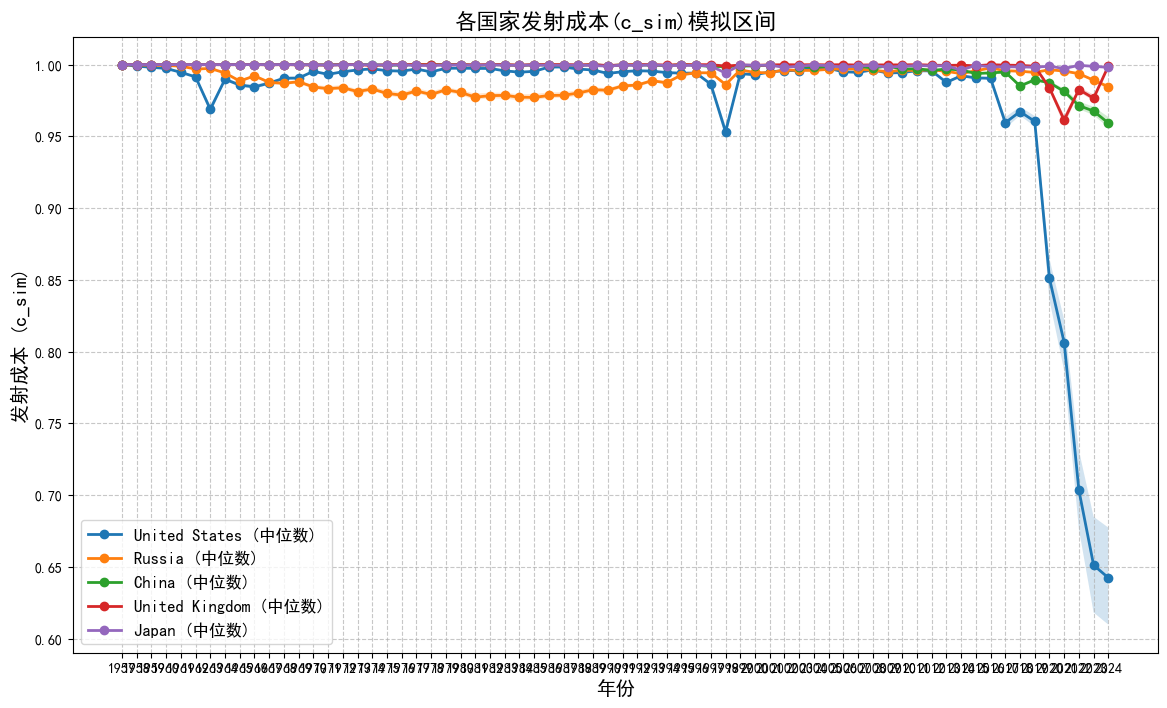

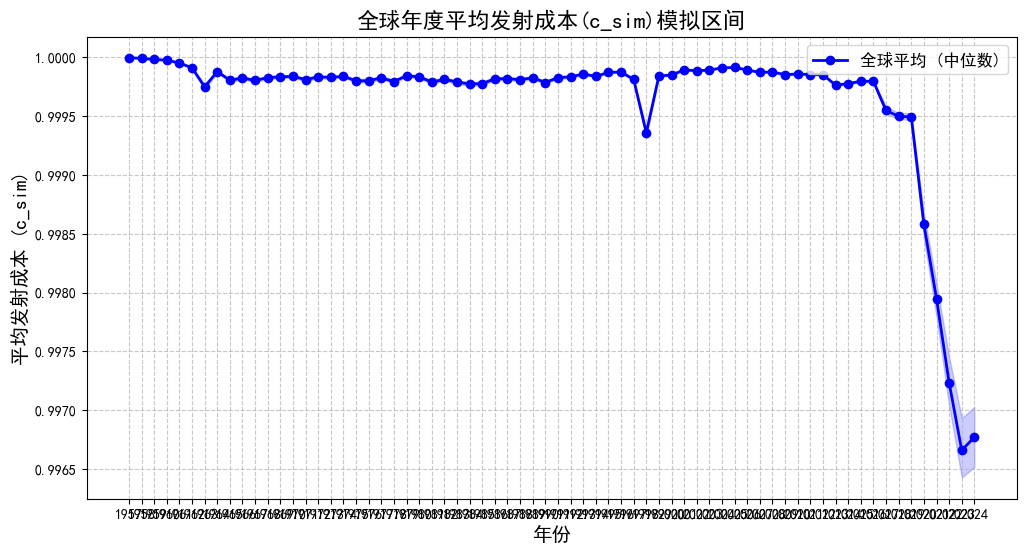


边际成本(c_sim)蒙特卡洛模拟结果汇总:
总模拟次数: 100
分析国家数: 135
分析年份: [1957, 1958, 1959, 1960, 1961, 1962, 1963, 1964, 1965, 1966, 1967, 1968, 1969, 1970, 1971, 1972, 1973, 1974, 1975, 1976, 1977, 1978, 1979, 1980, 1981, 1982, 1983, 1984, 1985, 1986, 1987, 1988, 1989, 1990, 1991, 1992, 1993, 1994, 1995, 1996, 1997, 1998, 1999, 2000, 2001, 2002, 2003, 2004, 2005, 2006, 2007, 2008, 2009, 2010, 2011, 2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024]

部分主要国家的发射成本(c_sim)区间估计:

United States:
  1957: 1.000000 - 1.000000 - 1.000000
  1958: 0.998808 - 0.998913 - 0.999014
  1959: 0.997956 - 0.998145 - 0.998302
  1960: 0.997104 - 0.997322 - 0.997608
  1961: 0.994202 - 0.994624 - 0.995198
  1962: 0.990618 - 0.991419 - 0.992249
  1963: 0.965831 - 0.968813 - 0.971744
  1964: 0.988733 - 0.989831 - 0.990698
  1965: 0.984479 - 0.985716 - 0.987083
  1966: 0.983238 - 0.984473 - 0.985966
  1967: 0.985961 - 0.987094 - 0.988321
  1968: 0.989589 - 0.990521 - 0.991401
  1969: 0.989588 - 0.990631 - 

In [13]:



# 删除2025年的数据
df = df[df['year'] != 2025]
print(f"删除2025年数据后的数据集大小: {df.shape}")
print("\n年份范围：")
print(df['year'].unique())

# 首先按国家和年份排序
df = df.sort_values(['country', 'year'])

# 按国家分组并获取上一年的X_total_cum
df['prev_total_launch'] = df.groupby('country')['X_total_cum'].shift(1)

# 将1957年的prev_total_launch设置为0
df.loc[df['year'] == 1957, 'prev_total_launch'] = 0

# 计算每年所有国家的总发射量
annual_total = df.groupby('year')['flow_launch'].sum().reset_index()
annual_total.rename(columns={'flow_launch': 'annual_launch_total'}, inplace=True)

# 使用字典映射方式添加年度总发射量，避免merge可能导致的问题
annual_dict = dict(zip(annual_total['year'], annual_total['annual_launch_total']))
df['annual_launch_total'] = df['year'].map(annual_dict)

# 计算LHS，保留flow_launch
df['LHS'] = 1 - tau * df['prev_total_launch'] - tau * (df['annual_launch_total'] + df['flow_launch'])

# 检查是否还有NaN值
nan_rows = df[df['prev_total_launch'].isna()]
if len(nan_rows) > 0:
    print(f"警告：还有{len(nan_rows)}行prev_total_launch是NaN值")
    # 对于其他可能的NaN值，使用0填充
    df['prev_total_launch'] = df['prev_total_launch'].fillna(0)
    
    # 重新计算LHS
    df['LHS'] = 1 - tau * df['prev_total_launch'] - tau * (df['annual_launch_total'] + df['flow_launch'])

# 3. 模拟分析
# ... existing code ...

def simulation_analysis(df, tau=tau, gamma=gamma):
    # 直接计算c_sim，跳过LHS的中间步骤
    df['c_sim'] = (1 - tau * df['prev_total_launch'] - 
                   tau * df['annual_launch_total'] - 
                   (tau + gamma) * df['flow_launch'])
    
    # 创建发射过和未发射过的国家分组
    country_launches = df.groupby('country')['flow_launch'].sum()
    launched_countries = country_launches[country_launches > 0].index
    non_launched_countries = country_launches[country_launches == 0].index
    
    launched_data = df[df['country'].isin(launched_countries)]
    non_launched_data = df[df['country'].isin(non_launched_countries)]
    
    return df, launched_data, non_launched_data

# ... existing code ...

# 第一年的数据会是NaN，可以用当年的total_launch填充
df.loc[df['prev_total_launch'].isna(), 'LHS'] = 1 - tau * df.loc[df['prev_total_launch'].isna(), 'X_total_cum'] - tau * df.loc[df['prev_total_launch'].isna(), 'flow_launch']

# 运行模拟分析函数
df_sim, launched_data, non_launched_data = simulation_analysis(df, tau=tau, gamma=gamma)

# 保存完整的模拟分析结果
output_path = "D:/Academic/RUC/Zheng/太空经济/CongestionTax/data/temp/complete_simulation_data.csv"
df_sim.to_csv(output_path, index=False)
print(f"完整模拟分析数据已保存至：{output_path}")

# 保存发射国和非发射国的数据
launched_path = "D:/Academic/RUC/Zheng/太空经济/CongestionTax/data/temp/launched_countries_data.csv"
non_launched_path = "D:/Academic/RUC/Zheng/太空经济/CongestionTax/data/temp/non_launched_countries_data.csv"

launched_data.to_csv(launched_path, index=False)
non_launched_data.to_csv(non_launched_path, index=False)

print(f"发射过卫星的国家数据已保存至：{launched_path}")
print(f"未发射过卫星的国家数据已保存至：{non_launched_path}")

# 打印一些基本统计信息
print("\n基本统计信息:")
print(f"总数据条目: {len(df_sim)}")
print(f"发射国数量: {len(launched_data['country'].unique())}")
print(f"非发射国数量: {len(non_launched_data['country'].unique())}")

# 读取之前保存的模拟数据
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
import os


# 读取之前保存的完整模拟数据
data_path = "D:/Academic/RUC/Zheng/太空经济/CongestionTax/data/temp/launched_countries_data.csv"
df = pd.read_csv(data_path)

print(f"读取数据的形状: {df.shape}")
print("读取数据的列名:")
print(df.columns.tolist())

# 只保留发射过的国家数据
launched_countries = df.groupby('country')['flow_launch'].sum()
launched_countries = launched_countries[launched_countries > 0].index.tolist()
df_launch = df[df['country'].isin(launched_countries)].copy()

print(f"发射过的国家数量: {len(launched_countries)}")
print(f"包含发射国的数据形状: {df_launch.shape}")

# 在 Monte Carlo 模拟之前定义输出目录
output_dir = "D:/Academic/RUC/Zheng/太空经济/CongestionTax/data/results/"

# 确保输出目录存在
import os
if not os.path.exists(output_dir):
    os.makedirs(output_dir)


# Monte Carlo模拟函数
def monte_carlo_simulation(df, n_sims=1000, error_range=0.1):
    """
    使用蒙特卡洛方法模拟理论最优发射量X_bar和对应的c_sim
    
    参数:
    df: 包含flow_launch的DataFrame
    n_sims: 模拟次数
    error_range: 误差范围 (0.1表示±10%)
    
    返回:
    包含模拟结果的DataFrame
    """
    # 创建存储所有模拟结果的列表
    all_results = []
    
    # 对每个模拟运行进行循环
    for sim in tqdm(range(n_sims), desc="Monte Carlo模拟"):
        # 创建当前模拟的DataFrame副本
        sim_df = df.copy()
        
        # 只对有实际发射的情况(flow_launch >= 1)生成随机误差
        mask = sim_df['flow_launch'] >= 1
        
        # 对有发射的记录生成随机误差因子 (0.9-1.1之间均匀分布)
        error_factors = np.random.uniform(1-error_range, 1+error_range, size=mask.sum())
        
        # 计算理论最优发射量X_bar
        sim_df.loc[mask, 'X_bar'] = sim_df.loc[mask, 'flow_launch'] * error_factors
        sim_df.loc[~mask, 'X_bar'] = sim_df.loc[~mask, 'flow_launch']  # 对于flow_launch < 1的情况，X_bar = flow_launch
        
        # 计算基于X_bar的c_sim
        sim_df['c_sim_bar'] = (1 - tau * sim_df['prev_total_launch'] - 
                       tau * sim_df['annual_launch_total'] - 
                       tau * sim_df['X_bar']) - (gamma * sim_df['X_bar'])
        
        # 添加模拟ID
        sim_df['sim_id'] = sim
        
        # 添加到结果列表
        all_results.append(sim_df)
    
    # 合并所有模拟结果
    return pd.concat(all_results, ignore_index=True)

# 运行Monte Carlo模拟
mc_results = monte_carlo_simulation(df_launch, n_sims=1000, error_range=0.1)

# 计算每个国家每年c_sim的统计数据
c_sim_stats = mc_results.groupby(['country', 'year'])['c_sim_bar'].agg(
    lower_bound=lambda x: x.quantile(0.025),  # 2.5%分位数作为下界
    median=lambda x: x.median(),              # 中位数
    upper_bound=lambda x: x.quantile(0.975)   # 97.5%分位数作为上界
).reset_index()

# 创建完整的面板数据
# 1. 首先获取原始数据中发射国家的数据
panel_data = df_launch.copy()

# 2. 合并c_sim统计数据
panel_data = panel_data.merge(
    c_sim_stats,
    on=['country', 'year'],
    how='left'
)

# 3. 重命名列以更清晰地表示含义
panel_data = panel_data.rename(columns={
    'lower_bound': 'c_sim_lower',
    'median': 'c_sim_median',
    'upper_bound': 'c_sim_upper'
})

# 保存完整的面板数据
panel_data.to_csv(f"{output_dir}complete_panel_data.csv", index=False)
print(f"完整的面板数据已保存至: {output_dir}complete_panel_data.csv")

# 继续保存原来的c_sim_bounds（如果仍然需要）
c_sim_stats.to_csv(f"{output_dir}c_sim_bounds.csv", index=False)
# 保存完整的蒙特卡洛模拟结果（如有需要）
# mc_results.to_csv(f"{output_dir}monte_carlo_full_results.csv", index=False)

# 可视化关键国家的c_sim边界
def plot_country_c_sim_bounds(stats_df, countries, years=None, figsize=(14, 8)):
    """为选定国家绘制c_sim的上下边界和中位数"""
    if years is None:
        years = sorted(stats_df['year'].unique())
    
    plt.figure(figsize=figsize)
    
    for country in countries:
        country_data = stats_df[stats_df['country'] == country]
        
        if len(country_data) == 0:
            print(f"国家 {country} 没有数据")
            continue
            
        plt.plot(country_data['year'], country_data['median'], marker='o', linewidth=2, label=f"{country} (中位数)")
        plt.fill_between(
            country_data['year'], 
            country_data['lower_bound'], 
            country_data['upper_bound'], 
            alpha=0.2
        )
    
    plt.title('各国家发射成本(c_sim)模拟区间', fontsize=16)
    plt.xlabel('年份', fontsize=14)
    plt.ylabel('发射成本 (c_sim)', fontsize=14)
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.legend(fontsize=12)
    plt.xticks(years)
    
    # 保存图表
    plt.savefig(f"{output_dir}country_c_sim_bounds.png", dpi=300, bbox_inches='tight')
    plt.show()

# 选择发射量最多的5个国家进行可视化
top_countries = df_launch.groupby('country')['flow_launch'].sum().nlargest(5).index.tolist()
print(f"发射量最多的5个国家: {top_countries}")

# 绘制这些国家的c_sim边界
plot_country_c_sim_bounds(c_sim_stats, top_countries)

# 增加一个汇总分析，按年份查看所有国家c_sim的分布
yearly_c_sim = mc_results.groupby(['year', 'sim_id'])['c_sim_bar'].mean().reset_index()
yearly_c_sim_stats = yearly_c_sim.groupby('year')['c_sim_bar'].agg(
    lower_bound=lambda x: x.quantile(0.025),
    median=lambda x: x.median(),
    upper_bound=lambda x: x.quantile(0.975)
).reset_index()

# 可视化按年份的总体c_sim趋势
plt.figure(figsize=(12, 6))
plt.plot(yearly_c_sim_stats['year'], yearly_c_sim_stats['median'], marker='o', linewidth=2, color='blue', label='全球平均 (中位数)')
plt.fill_between(
    yearly_c_sim_stats['year'], 
    yearly_c_sim_stats['lower_bound'], 
    yearly_c_sim_stats['upper_bound'], 
    alpha=0.2,
    color='blue'
)

plt.title('全球年度平均发射成本(c_sim)模拟区间', fontsize=16)
plt.xlabel('年份', fontsize=14)
plt.ylabel('平均发射成本 (c_sim)', fontsize=14)
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend(fontsize=12)
plt.xticks(yearly_c_sim_stats['year'].unique())

# 保存图表
plt.savefig(f"{output_dir}yearly_global_c_sim_bounds.png", dpi=300, bbox_inches='tight')
plt.show()

# 输出最终统计结果
print("\n边际成本(c_sim)蒙特卡洛模拟结果汇总:")
print(f"总模拟次数: {len(mc_results['sim_id'].unique())}")
print(f"分析国家数: {len(c_sim_stats['country'].unique())}")
print(f"分析年份: {sorted(c_sim_stats['year'].unique())}")

# 输出部分国家的c_sim区间结果展示
print("\n部分主要国家的发射成本(c_sim)区间估计:")
for country in top_countries[:3]:  # 只展示前3个国家
    country_data = c_sim_stats[c_sim_stats['country'] == country].sort_values('year')
    print(f"\n{country}:")
    for _, row in country_data.iterrows():
        print(f"  {int(row['year'])}: {row['lower_bound']:.6f} - {row['median']:.6f} - {row['upper_bound']:.6f}")


In [3]:
# 导入并筛选主要发射国数据
import pandas as pd
import numpy as np

# 读取完整面板数据
panel_data = pd.read_csv(f"{output_dir}complete_panel_data.csv")

# 先创建2014-2023的临时数据框来识别major players
temp_recent = panel_data[
    (panel_data['year'] >= 2014) & 
    (panel_data['year'] <= 2023)
].copy()

# 创建2013-2024的临时数据框来检查独立发射能力
temp_capability = panel_data[
    (panel_data['year'] >= 2013) & 
    (panel_data['year'] <= 2024)
].copy()

# 找出具有独立发射能力的国家（至少有一次发射量>=1）
capable_countries = temp_capability.groupby('country')['flow_launch'].max() >= 1
capable_countries = capable_countries[capable_countries].index.tolist()

# 计算每个国家在2014-2023这十年中有发射的年份数量
country_launch_years = (temp_recent['flow_launch'] > 0)\
    .groupby(temp_recent['country'])\
    .sum()\
    .reset_index()
country_launch_years.columns = ['country', 'launch_years']

# 筛选出发射年份超过5年且具有独立发射能力的国家
major_players = country_launch_years[
    (country_launch_years['launch_years'] >= 6) & 
    (country_launch_years['country'].isin(capable_countries))
]['country'].tolist()

# 创建主要发射国的数据集（使用完整时间段的数据）
major_player_data = panel_data[
    panel_data['country'].isin(major_players)
].copy()

# 按国家和年份排序
major_player_data = major_player_data.sort_values(['country', 'year'])

# 输出分析结果
print("\n主要发射国分析:")
print(f"符合条件的主要发射国数量: {len(major_players)}")
print("\n主要发射国列表（2014-2023期间的发射情况）:")
for country in major_players:
    # 2014-2023期间的发射年数
    launch_years = country_launch_years[
        country_launch_years['country'] == country
    ]['launch_years'].iloc[0]
    # 2014-2023期间的总发射次数
    recent_launches = temp_recent[
        temp_recent['country'] == country
    ]['flow_launch'].sum()
    # 所有年份的总发射次数
    total_launches = major_player_data[
        major_player_data['country'] == country
    ]['flow_launch'].sum()
    # 最大单次发射量（用于显示发射能力）
    max_launch = temp_capability[
        temp_capability['country'] == country
    ]['flow_launch'].max()
    print(f"{country}: 2014-2023期间有{launch_years}年发射记录，该期间发射次数: {recent_launches:.0f}，"
          f"总发射次数: {total_launches:.0f}，最大单次发射量: {max_launch:.1f}")

# 保存主要发射国数据
major_player_data.to_csv(f"{output_dir}major_player_data.csv", index=False)
print(f"\n主要发射国完整时间序列数据已保存至: {output_dir}major_player_data.csv")

# 创建主要发射国年度发射量统计
yearly_launches = major_player_data.pivot_table(
    index='year',
    columns='country',
    values='flow_launch',
    aggfunc='sum'
).fillna(0)

print("\n各主要发射国年度发射量:")
print(yearly_launches)


主要发射国分析:
符合条件的主要发射国数量: 61

主要发射国列表（2014-2023期间的发射情况）:
Algeria: 2014-2023期间有6.0年发射记录，该期间发射次数: 4，总发射次数: 6，最大单次发射量: 3.0
Angola: 2014-2023期间有6.0年发射记录，该期间发射次数: 2，总发射次数: 2，最大单次发射量: 1.0
Argentina: 2014-2023期间有10.0年发射记录，该期间发射次数: 48，总发射次数: 65，最大单次发射量: 14.0
Australia: 2014-2023期间有9.0年发射记录，该期间发射次数: 28，总发射次数: 53，最大单次发射量: 11.0
Bangladesh: 2014-2023期间有6.0年发射记录，该期间发射次数: 1，总发射次数: 2，最大单次发射量: 1.0
Belgium: 2014-2023期间有10.0年发射记录，该期间发射次数: 13，总发射次数: 27，最大单次发射量: 4.4
Brazil: 2014-2023期间有8.0年发射记录，该期间发射次数: 8，总发射次数: 24，最大单次发射量: 2.0
Bulgaria: 2014-2023期间有10.0年发射记录，该期间发射次数: 7，总发射次数: 13，最大单次发射量: 2.1
Canada: 2014-2023期间有10.0年发射记录，该期间发射次数: 48，总发射次数: 105，最大单次发射量: 8.3
Chile: 2014-2023期间有6.0年发射记录，该期间发射次数: 4，总发射次数: 6，最大单次发射量: 3.0
China: 2014-2023期间有10.0年发射记录，该期间发射次数: 890，总发射次数: 1378，最大单次发射量: 258.0
Commonwealth of Independent States: 2014-2023期间有10.0年发射记录，该期间发射次数: 337，总发射次数: 4463，最大单次发射量: 100.1
Croatia: 2014-2023期间有10.0年发射记录，该期间发射次数: 2，总发射次数: 7，最大单次发射量: 1.3
Czech Republic: 2014-2023期间有10.0年发射记录，该期间发射次数: 7，总发射次数: 23，最大单次发

In [4]:
#ARIMA 寻找最优模型进行2024年测试

import pandas as pd
import numpy as np
from statsmodels.tsa.arima.model import ARIMA
import itertools
import warnings
warnings.filterwarnings('ignore')

# 定义输出目录
output_dir = "D:/Academic/RUC/Zheng/太空经济/CongestionTax/data/results/"

# 读取数据
df = pd.read_csv(f"{output_dir}major_player_data.csv")

# 获取所有国家列表 - 修正变量名
countries = df['country'].unique()  # 使用小写的'country'列名

# 创建存储2024年预测结果的DataFrame
prediction_2024 = pd.DataFrame(columns=['country', 'c_pred_lower', 'c_pred_median', 'c_pred_upper'])

# 手动实现寻找最优ARIMA模型的函数
def find_best_arima(series, max_p=3, max_d=2, max_q=3):
    best_aic = float('inf')
    best_order = None
    
    # 对可能的p,d,q参数进行网格搜索
    p_range = range(0, max_p + 1)
    d_range = range(0, max_d + 1)
    q_range = range(0, max_q + 1)
    
    for p, d, q in itertools.product(p_range, d_range, q_range):
        if p == 0 and q == 0:
            continue  # 避免非ARIMA模型
        
        try:
            model = ARIMA(series, order=(p, d, q))
            model_fit = model.fit()
            
            if model_fit.aic < best_aic:
                best_aic = model_fit.aic
                best_order = (p, d, q)
        except:
            continue
    
    if best_order is None:
        # 如果所有模型都失败，返回一个简单的模型
        best_order = (1, 1, 0)
    
    return best_order

for country in countries:
    # 筛选该国家的数据 - 修正变量名和列名
    country_data = df[df['country'] == country]
    
    # 检查是否有足够的历史数据进行ARIMA建模（至少需要5年数据）
    if len(country_data[country_data['year'] <= 2023]) < 5:  # 假设'year'也是小写
        print(f"国家 {country} 的历史数据不足，无法进行ARIMA建模")
        # 对于数据不足的国家，可以使用最近一年的数据作为预测值
        if len(country_data[country_data['year'] == 2023]) > 0:
            last_year = country_data[country_data['year'] == 2023].iloc[0]
            new_row = {
                'country': country,
                'c_pred_lower': last_year['c_sim_lower'],
                'c_pred_median': last_year['c_sim_median'],
                'c_pred_upper': last_year['c_sim_upper']
            }
            prediction_2024 = pd.concat([prediction_2024, pd.DataFrame([new_row])], ignore_index=True)
        continue
    
    # 提取该国家的时间序列数据（2023年及之前）
    ts_data_lower = country_data[country_data['year'] <= 2023][['year', 'c_sim_lower']]
    ts_data_median = country_data[country_data['year'] <= 2023][['year', 'c_sim_median']]
    ts_data_upper = country_data[country_data['year'] <= 2023][['year', 'c_sim_upper']]
    
    # 将年份设为索引
    ts_data_lower.set_index('year', inplace=True)
    ts_data_median.set_index('year', inplace=True)
    ts_data_upper.set_index('year', inplace=True)
    
    print(f"正在为国家 {country} 寻找最优ARIMA模型...")
    
    try:
        # 使用自定义函数找到最优模型参数（基于c_sim_median）
        order = find_best_arima(ts_data_median['c_sim_median'])
        print(f"国家 {country} 的最优ARIMA模型参数: {order}")
        
        # 使用最优模型参数分别对三个时间序列进行预测
        # 对c_sim_lower进行预测
        model_lower = ARIMA(ts_data_lower['c_sim_lower'], order=order)
        model_lower_fit = model_lower.fit()
        forecast_lower = model_lower_fit.forecast(steps=1)
        
        # 对c_sim_median进行预测
        model_median = ARIMA(ts_data_median['c_sim_median'], order=order)
        model_median_fit = model_median.fit()
        forecast_median = model_median_fit.forecast(steps=1)
        
        # 对c_sim_upper进行预测
        model_upper = ARIMA(ts_data_upper['c_sim_upper'], order=order)
        model_upper_fit = model_upper.fit()
        forecast_upper = model_upper_fit.forecast(steps=1)
        
        # 保存预测结果
        new_row = {
            'country': country,
            'c_pred_lower': forecast_lower.iloc[0],
            'c_pred_median': forecast_median.iloc[0],
            'c_pred_upper': forecast_upper.iloc[0]
        }
        prediction_2024 = pd.concat([prediction_2024, pd.DataFrame([new_row])], ignore_index=True)
        
        print(f"国家 {country} 的2024年预测完成")
        
    except Exception as e:
        print(f"国家 {country} 的ARIMA预测失败: {str(e)}")
        # 如果模型失败，可以使用最近一年的数据作为预测值
        if len(country_data[country_data['year'] == 2023]) > 0:
            last_year = country_data[country_data['year'] == 2023].iloc[0]
            new_row = {
                'country': country,
                'c_pred_lower': last_year['c_sim_lower'],
                'c_pred_median': last_year['c_sim_median'],
                'c_pred_upper': last_year['c_sim_upper']
            }
            prediction_2024 = pd.concat([prediction_2024, pd.DataFrame([new_row])], ignore_index=True)

# 将预测结果保存到CSV文件 - 使用正确的输出路径
prediction_2024.to_csv(f'{output_dir}arima_predictions_2024.csv', index=False)
print("所有国家的2024年成本预测已完成并保存")

# 显示预测结果
print("\n2024年各国成本预测结果:")
print(prediction_2024)

正在为国家 Algeria 寻找最优ARIMA模型...
国家 Algeria 的最优ARIMA模型参数: (0, 0, 1)
国家 Algeria 的2024年预测完成
正在为国家 Angola 寻找最优ARIMA模型...
国家 Angola 的最优ARIMA模型参数: (1, 0, 0)
国家 Angola 的2024年预测完成
正在为国家 Argentina 寻找最优ARIMA模型...
国家 Argentina 的最优ARIMA模型参数: (0, 1, 2)
国家 Argentina 的2024年预测完成
正在为国家 Australia 寻找最优ARIMA模型...
国家 Australia 的最优ARIMA模型参数: (2, 0, 1)
国家 Australia 的2024年预测完成
正在为国家 Bangladesh 寻找最优ARIMA模型...
国家 Bangladesh 的最优ARIMA模型参数: (1, 0, 0)
国家 Bangladesh 的2024年预测完成
正在为国家 Belgium 寻找最优ARIMA模型...
国家 Belgium 的最优ARIMA模型参数: (3, 0, 0)
国家 Belgium 的2024年预测完成
正在为国家 Brazil 寻找最优ARIMA模型...
国家 Brazil 的最优ARIMA模型参数: (1, 0, 0)
国家 Brazil 的2024年预测完成
正在为国家 Bulgaria 寻找最优ARIMA模型...
国家 Bulgaria 的最优ARIMA模型参数: (1, 0, 1)
国家 Bulgaria 的2024年预测完成
正在为国家 Canada 寻找最优ARIMA模型...
国家 Canada 的最优ARIMA模型参数: (2, 0, 1)
国家 Canada 的2024年预测完成
正在为国家 Chile 寻找最优ARIMA模型...
国家 Chile 的最优ARIMA模型参数: (1, 0, 0)
国家 Chile 的2024年预测完成
正在为国家 China 寻找最优ARIMA模型...
国家 China 的最优ARIMA模型参数: (3, 2, 0)
国家 China 的2024年预测完成
正在为国家 Commonwealth of Independent States 寻找最优ARIMA模

In [5]:

import pandas as pd
import numpy as np
from statsmodels.tsa.arima.model import ARIMA
import warnings
warnings.filterwarnings('ignore')

# 定义输出目录
output_dir = "D:/Academic/RUC/Zheng/太空经济/CongestionTax/data/results/"

# 读取数据
df = pd.read_csv(f"{output_dir}major_player_data.csv")

# 获取所有国家列表
countries = df['country'].unique()

# 创建存储2024年预测结果的DataFrame
prediction_2024 = pd.DataFrame(columns=['country', 'c_pred_lower', 'c_pred_median', 'c_pred_upper'])

# 对所有国家使用固定的ARIMA(1,1,1)模型进行预测
for country in countries:
    # 筛选该国家的数据
    country_data = df[df['country'] == country]
    
    # 检查是否有足够的历史数据进行ARIMA建模（至少需要5年数据）
    if len(country_data[country_data['year'] <= 2023]) < 5:
        print(f"国家 {country} 的历史数据不足，无法进行ARIMA建模")
        # 对于数据不足的国家，使用最近一年的数据作为预测值
        if len(country_data[country_data['year'] == 2023]) > 0:
            last_year = country_data[country_data['year'] == 2023].iloc[0]
            new_row = {
                'country': country,
                'c_pred_lower': last_year['c_sim_lower'],
                'c_pred_median': last_year['c_sim_median'],
                'c_pred_upper': last_year['c_sim_upper']
            }
            prediction_2024 = pd.concat([prediction_2024, pd.DataFrame([new_row])], ignore_index=True)
        continue
    
    # 提取该国家的时间序列数据（2023年及之前）
    ts_data_lower = country_data[country_data['year'] <= 2023][['year', 'c_sim_lower']]
    ts_data_median = country_data[country_data['year'] <= 2023][['year', 'c_sim_median']]
    ts_data_upper = country_data[country_data['year'] <= 2023][['year', 'c_sim_upper']]
    
    # 将年份设为索引
    ts_data_lower.set_index('year', inplace=True)
    ts_data_median.set_index('year', inplace=True)
    ts_data_upper.set_index('year', inplace=True)
    
    print(f"正在为国家 {country} 应用ARIMA(1,0,1)模型...")
    
    try:
        # 使用固定的ARIMA(1,1,1)模型进行预测
        order = (1, 0, 1)  # 固定使用ARIMA(1,0,1)
        
        # 对c_sim_lower进行预测
        model_lower = ARIMA(ts_data_lower['c_sim_lower'], order=order)
        model_lower_fit = model_lower.fit()
        forecast_lower = model_lower_fit.forecast(steps=1)
        
        # 对c_sim_median进行预测
        model_median = ARIMA(ts_data_median['c_sim_median'], order=order)
        model_median_fit = model_median.fit()
        forecast_median = model_median_fit.forecast(steps=1)
        
        # 对c_sim_upper进行预测
        model_upper = ARIMA(ts_data_upper['c_sim_upper'], order=order)
        model_upper_fit = model_upper.fit()
        forecast_upper = model_upper_fit.forecast(steps=1)
        
        # 保存预测结果
        new_row = {
            'country': country,
            'c_pred_lower': forecast_lower.iloc[0],
            'c_pred_median': forecast_median.iloc[0],
            'c_pred_upper': forecast_upper.iloc[0]
        }
        prediction_2024 = pd.concat([prediction_2024, pd.DataFrame([new_row])], ignore_index=True)
        
        print(f"国家 {country} 的2024年预测完成")
        
    except Exception as e:
        print(f"国家 {country} 的ARIMA预测失败: {str(e)}")
        # 如果模型失败，使用最近一年的数据作为预测值
        if len(country_data[country_data['year'] == 2023]) > 0:
            last_year = country_data[country_data['year'] == 2023].iloc[0]
            new_row = {
                'country': country,
                'c_pred_lower': last_year['c_sim_lower'],
                'c_pred_median': last_year['c_sim_median'],
                'c_pred_upper': last_year['c_sim_upper']
            }
            prediction_2024 = pd.concat([prediction_2024, pd.DataFrame([new_row])], ignore_index=True)

# 将预测结果保存到CSV文件
prediction_2024.to_csv(f'{output_dir}arima111_predictions_2024.csv', index=False)
print("所有国家的2024年成本预测已完成并保存")

# 显示预测结果
print("\n2024年各国成本预测结果:")
print(prediction_2024)


正在为国家 Algeria 应用ARIMA(1,0,1)模型...
国家 Algeria 的2024年预测完成
正在为国家 Angola 应用ARIMA(1,0,1)模型...
国家 Angola 的2024年预测完成
正在为国家 Argentina 应用ARIMA(1,0,1)模型...
国家 Argentina 的2024年预测完成
正在为国家 Australia 应用ARIMA(1,0,1)模型...
国家 Australia 的2024年预测完成
正在为国家 Bangladesh 应用ARIMA(1,0,1)模型...
国家 Bangladesh 的2024年预测完成
正在为国家 Belgium 应用ARIMA(1,0,1)模型...
国家 Belgium 的2024年预测完成
正在为国家 Brazil 应用ARIMA(1,0,1)模型...
国家 Brazil 的2024年预测完成
正在为国家 Bulgaria 应用ARIMA(1,0,1)模型...
国家 Bulgaria 的2024年预测完成
正在为国家 Canada 应用ARIMA(1,0,1)模型...
国家 Canada 的2024年预测完成
正在为国家 Chile 应用ARIMA(1,0,1)模型...
国家 Chile 的2024年预测完成
正在为国家 China 应用ARIMA(1,0,1)模型...
国家 China 的2024年预测完成
正在为国家 Commonwealth of Independent States 应用ARIMA(1,0,1)模型...
国家 Commonwealth of Independent States 的2024年预测完成
正在为国家 Croatia 应用ARIMA(1,0,1)模型...
国家 Croatia 的2024年预测完成
正在为国家 Czech Republic 应用ARIMA(1,0,1)模型...
国家 Czech Republic 的2024年预测完成
正在为国家 Denmark 应用ARIMA(1,0,1)模型...
国家 Denmark 的2024年预测完成
正在为国家 Egypt 应用ARIMA(1,0,1)模型...
国家 Egypt 的2024年预测完成
正在为国家 Estonia 应用ARIMA(1,0,1)模型...
国家 E

Found 61 records for year 2024
Top 10 countries by launch volume: ['United States', 'China', 'United Kingdom', 'Commonwealth of Independent States', 'Italy', 'Argentina', 'France', 'Australia', 'Spain', 'South Korea']
Launch volume predictions for 2024 completed and saved (using tau=5e-11, gamma=0.0001557692307692)

Comparison of predicted and actual launch volumes for top 5 countries in 2024:
                               country  flow_launch_pred_lower  \
2                            Argentina               10.610833   
3                            Australia                1.196232   
10                               China              260.139830   
11  Commonwealth of Independent States               60.660565   
18                              France                8.150830   
27                               Italy               23.659149   
49                         South Korea                4.676949   
50                               Spain               11.747007   
58       

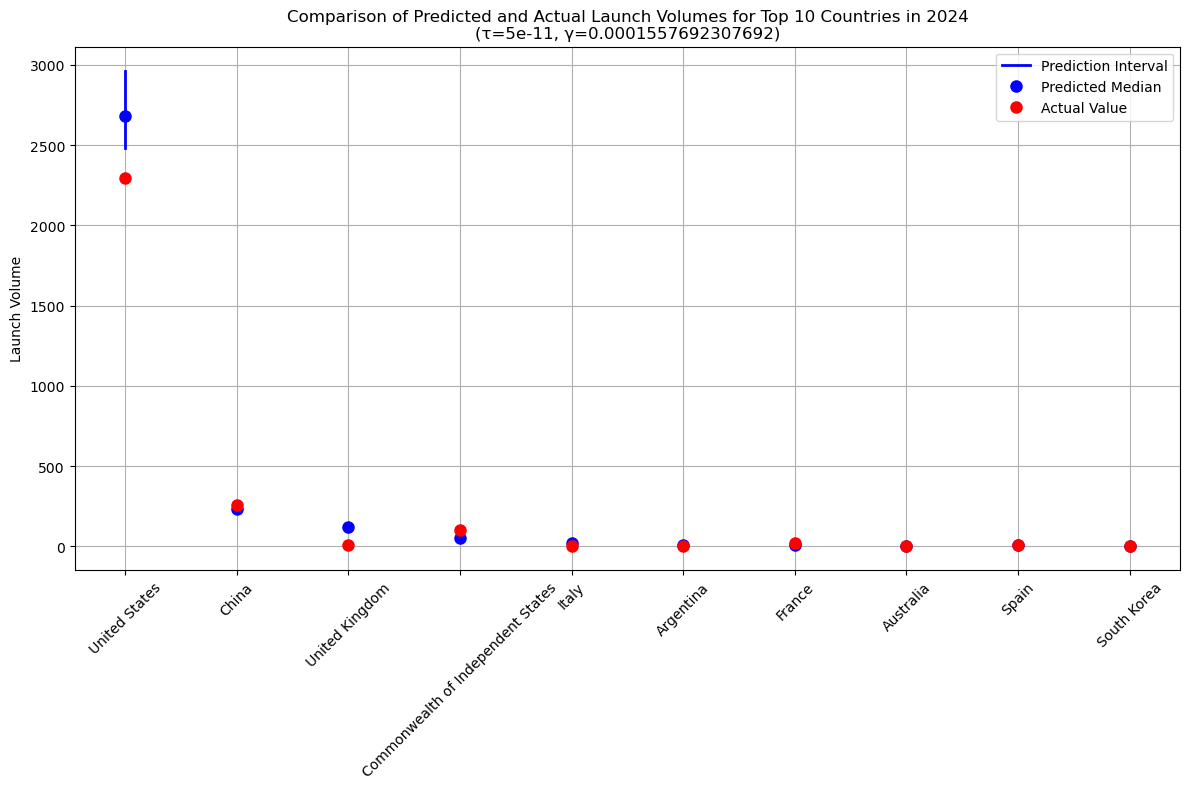

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
# 设置全局字体，确保支持英文
matplotlib.rcParams['font.family'] = 'DejaVu Sans'

# 定义输出目录
output_dir = "D:/Academic/RUC/Zheng/太空经济/CongestionTax/data/results/"

# 加载原始数据和ARIMA预测结果
df = pd.read_csv(f"{output_dir}major_player_data.csv")
arima_predictions = pd.read_csv(f"{output_dir}arima_predictions_2024.csv")



# 创建一个新的DataFrame来存储2024年的预测发射量
pred_2024 = pd.DataFrame(columns=['country', 'flow_launch_pred_lower', 'flow_launch_pred_median', 
                                 'flow_launch_pred_upper', 'flow_launch_actual'])

# 获取2023年的总发射量数据（用作St-1）
df_2023 = df[df['year'] == 2023]
S_prev = df_2023['annual_launch_total'].sum() if len(df_2023) > 0 else 0

# 确保我们有2024年的数据
df_2024 = df[df['year'] == 2024]
if len(df_2024) == 0:
    print("Warning: No 2024 data found in major_player_data")
else:
    print(f"Found {len(df_2024)} records for year 2024")

# 找出发射量前五的国家（基于2023年数据）
top10_countries = df_2023.sort_values('flow_launch', ascending=False)['country'].unique()[:10]
if len(top10_countries) < 10:  # 如果2023年数据不足5个国家
    # 使用所有年份数据
    top10_countries = df.groupby('country')['flow_launch'].sum().sort_values(ascending=False).index[:10]

print(f"Top 10 countries by launch volume: {list(top10_countries)}")

# 为每个预测情景(lower, median, upper)计算所有国家的发射量
for scenario in ['lower', 'median', 'upper']:
    # 创建临时数据框存储计算中间结果
    temp_data = pd.DataFrame(columns=['country', 'c_pred', 'd', 'lambda'])
    
    # 首先计算每个国家的d值和lambda值
    for country in arima_predictions['country'].unique():
        # 获取该国家的成本预测数据
        country_pred = arima_predictions[arima_predictions['country'] == country]
        
        if len(country_pred) == 0:
            continue
        
        # 使用固定的gamma值 - 不再从数据中获取
        # 获取预测的成本值
        c_pred = country_pred[f'c_pred_{scenario}'].iloc[0]
        
        # 计算d值 - 使用固定的tau和gamma
        d = 1 / (tau + gamma)
        
        # 添加到临时数据框
        new_row = {
            'country': country,
            'c_pred': c_pred,
            'd': d
        }
        temp_data = pd.concat([temp_data, pd.DataFrame([new_row])], ignore_index=True)
    
    # 计算lambda值
    sum_d = temp_data['d'].sum()
    temp_data['lambda'] = temp_data['d'] / (1/tau + sum_d)
    
    # 计算lambda*c的总和
    sum_lambda_c = (temp_data['lambda'] * temp_data['c_pred']).sum()
    
    # 计算每个国家的发射量
    for country in temp_data['country']:
        row = temp_data[temp_data['country'] == country].iloc[0]
        d = row['d']
        c_pred = row['c_pred']
        
        # 使用公式: xit = dit[(1 - τSt-1 - cit) - Σj∈N λjt(1 - τSt-1 - cjt)]
        sum_lambda = temp_data['lambda'].sum()
        flow_launch_pred = d * ((1 - tau * S_prev) * (1 - sum_lambda) - c_pred + sum_lambda_c)
        
        # 确保发射量不为负
        flow_launch_pred = max(0, flow_launch_pred)
        
        # 获取2024年的实际发射量（直接从df中获取）
        country_2024 = df[(df['country'] == country) & (df['year'] == 2024)]
        flow_launch_actual = country_2024['flow_launch'].iloc[0] if len(country_2024) > 0 else None
        
        # 更新预测DataFrame
        if country in pred_2024['country'].values:
            idx = pred_2024[pred_2024['country'] == country].index[0]
            pred_2024.at[idx, f'flow_launch_pred_{scenario}'] = flow_launch_pred
            if flow_launch_actual is not None:  # 只在有实际值时更新
                pred_2024.at[idx, 'flow_launch_actual'] = flow_launch_actual
        else:
            new_row = {
                'country': country,
                f'flow_launch_pred_{scenario}': flow_launch_pred,
                'flow_launch_actual': flow_launch_actual
            }
            pred_2024 = pd.concat([pred_2024, pd.DataFrame([new_row])], ignore_index=True)

# 确保所有国家的实际发射量都已添加
for country in df_2024['country'].unique():
    if country not in pred_2024['country'].values:
        # 获取该国家2024年的实际发射量
        country_data = df_2024[df_2024['country'] == country]
        flow_launch_actual = country_data['flow_launch'].iloc[0] if len(country_data) > 0 else None
        
        if flow_launch_actual is not None:
            new_row = {
                'country': country,
                'flow_launch_actual': flow_launch_actual
            }
            pred_2024 = pd.concat([pred_2024, pd.DataFrame([new_row])], ignore_index=True)

# 整理预测DataFrame，确保所有列都存在
for scenario in ['lower', 'median', 'upper']:
    if f'flow_launch_pred_{scenario}' not in pred_2024.columns:
        pred_2024[f'flow_launch_pred_{scenario}'] = np.nan

# 保存预测结果
pred_2024.to_csv(f'{output_dir}flow_launch_predictions_2024.csv', index=False)
pred_2024.to_csv('flow_launch_predictions_2024.csv', index=False)
print(f"Launch volume predictions for 2024 completed and saved (using tau={tau}, gamma={gamma})")

# 分析前五大国家的预测结果
print("\nComparison of predicted and actual launch volumes for top 5 countries in 2024:")
top10_pred = pred_2024[pred_2024['country'].isin(top10_countries)]
print(top10_pred)

# 检查实际值是否在预测区间内
def check_in_interval(row):
    if pd.isna(row['flow_launch_actual']):
        return 'No actual data'
    elif (pd.isna(row['flow_launch_pred_lower']) or 
          pd.isna(row['flow_launch_pred_upper'])):
        return 'No prediction interval'
    elif (row['flow_launch_actual'] >= row['flow_launch_pred_lower'] and 
          row['flow_launch_actual'] <= row['flow_launch_pred_upper']):
        return 'Within prediction interval'
    else:
        return 'Outside prediction interval'

top10_pred['Prediction Assessment'] = top10_pred.apply(check_in_interval, axis=1)
print("\nPrediction interval assessment results:")
print(top10_pred[['country', 'flow_launch_pred_lower', 'flow_launch_pred_median', 
                'flow_launch_pred_upper', 'flow_launch_actual', 'Prediction Assessment']])

# 可视化前五大国家的预测结果
plt.figure(figsize=(12, 8))
for i, country in enumerate(top10_countries):
    if country in top10_pred['country'].values:
        country_data = top10_pred[top10_pred['country'] == country]
        x = i
        
        # 确保数据存在
        if ('flow_launch_pred_lower' in country_data.columns and 
            'flow_launch_pred_upper' in country_data.columns and
            not pd.isna(country_data['flow_launch_pred_lower'].iloc[0]) and
            not pd.isna(country_data['flow_launch_pred_upper'].iloc[0])):
            
            y_lower = country_data['flow_launch_pred_lower'].iloc[0]
            y_median = country_data['flow_launch_pred_median'].iloc[0]
            y_upper = country_data['flow_launch_pred_upper'].iloc[0]
            
            # 绘制预测区间
            plt.plot([x, x], [y_lower, y_upper], 'b-', linewidth=2)
            plt.plot(x, y_median, 'bo', markersize=8)
        
        # 如果有实际值，绘制实际值
        if ('flow_launch_actual' in country_data.columns and 
            not pd.isna(country_data['flow_launch_actual'].iloc[0])):
            
            y_actual = country_data['flow_launch_actual'].iloc[0]
            plt.plot(x, y_actual, 'ro', markersize=8)
            
            # 判断实际值是否在预测区间内
            has_prediction = ('flow_launch_pred_lower' in country_data.columns and 
                             'flow_launch_pred_upper' in country_data.columns and
                             not pd.isna(country_data['flow_launch_pred_lower'].iloc[0]) and
                             not pd.isna(country_data['flow_launch_pred_upper'].iloc[0]))
            
            if has_prediction:
                y_lower = country_data['flow_launch_pred_lower'].iloc[0]
                y_upper = country_data['flow_launch_pred_upper'].iloc[0]
                
                if y_actual >= y_lower and y_actual <= y_upper:
                    plt.text(x, y_actual*1.05, '√', color='green', fontsize=15)
             

plt.xticks(range(len(top10_countries)), top10_countries, rotation=45)
plt.ylabel('Launch Volume')
plt.title(f'Comparison of Predicted and Actual Launch Volumes for Top 10 Countries in 2024\n(τ={tau}, γ={gamma})')
plt.legend(['Prediction Interval', 'Predicted Median', 'Actual Value'])
plt.grid(True)
plt.tight_layout()

# 保存图表
plt.savefig(f'{output_dir}flow_launch_predictions_2024.png')
plt.savefig('flow_launch_predictions_2024.png')
print("Prediction chart has been saved")

plt.show()

In [7]:
import pandas as pd
import numpy as np
from statsmodels.tsa.arima.model import ARIMA
import matplotlib.pyplot as plt
import warnings
import itertools
import json

warnings.filterwarnings('ignore')

# 定义输出目录
output_dir = "D:/Academic/RUC/Zheng/太空经济/CongestionTax/data/results/"

# 读取数据
df = pd.read_csv(f"{output_dir}major_player_data.csv")
# 获取所有major player国家
all_countries = df['country'].unique()

# 手动实现寻找最优ARIMA模型的函数
def find_best_arima(series, max_p=3, max_d=2, max_q=3):
    best_aic = float('inf')
    best_order = None
    
    # 对可能的p,d,q参数进行网格搜索
    p_range = range(0, max_p + 1)
    d_range = range(0, max_d + 1)
    q_range = range(0, max_q + 1)
    
    for p, d, q in itertools.product(p_range, d_range, q_range):
        if p == 0 and q == 0:
            continue  # 避免非ARIMA模型
        
        try:
            model = ARIMA(series, order=(p, d, q))
            model_fit = model.fit()
            
            if model_fit.aic < best_aic:
                best_aic = model_fit.aic
                best_order = (p, d, q)
        except:
            continue
    
    if best_order is None:
        # 如果所有模型都失败，返回一个简单的模型
        best_order = (1, 1, 0)
    
    return best_order

# 存储每个国家的最佳ARIMA参数
best_arima_params = {}

# 对每个国家寻找最佳ARIMA参数
for country in all_countries:
    country_data = df[df['country'] == country].sort_values('year')
    
    # 检查是否有足够的历史数据（至少5年）
    if len(country_data[country_data['year'] <= 2024]) < 5:
        print(f"警告: {country} 的历史数据不足，使用默认模型(1,1,0)")
        best_arima_params[country] = (1, 1, 0)
        continue
    
    # 准备ARIMA模型的输入数据
    y = country_data[country_data['year'] <= 2024]['c_sim_median'].values
    
    try:
        # 找到最优ARIMA模型参数
        best_order = find_best_arima(y)
        best_arima_params[country] = best_order
        print(f"国家 {country} 的最优ARIMA模型参数: {best_order}")
        
    except Exception as e:
        print(f"国家 {country} 的ARIMA参数寻找失败: {str(e)}")
        # 使用默认参数
        best_arima_params[country] = (1, 1, 0)

# 将最佳参数保存到JSON文件
with open(f"{output_dir}best_arima_params.json", "w") as f:
    json.dump(best_arima_params, f)

print(f"所有国家的最佳ARIMA参数已保存至 {output_dir}best_arima_params.json")

国家 Algeria 的最优ARIMA模型参数: (0, 0, 1)
国家 Angola 的最优ARIMA模型参数: (1, 0, 0)
国家 Argentina 的最优ARIMA模型参数: (1, 0, 2)
国家 Australia 的最优ARIMA模型参数: (1, 0, 2)
国家 Bangladesh 的最优ARIMA模型参数: (1, 0, 0)
国家 Belgium 的最优ARIMA模型参数: (2, 0, 0)
国家 Brazil 的最优ARIMA模型参数: (1, 0, 0)
国家 Bulgaria 的最优ARIMA模型参数: (2, 0, 0)
国家 Canada 的最优ARIMA模型参数: (1, 0, 1)
国家 Chile 的最优ARIMA模型参数: (1, 0, 0)
国家 China 的最优ARIMA模型参数: (3, 2, 0)
国家 Commonwealth of Independent States 的最优ARIMA模型参数: (3, 0, 2)
国家 Croatia 的最优ARIMA模型参数: (1, 0, 0)
国家 Czech Republic 的最优ARIMA模型参数: (2, 0, 0)
国家 Denmark 的最优ARIMA模型参数: (1, 0, 0)
国家 Egypt 的最优ARIMA模型参数: (1, 0, 0)
国家 Estonia 的最优ARIMA模型参数: (1, 0, 1)
国家 Finland 的最优ARIMA模型参数: (2, 0, 0)
国家 France 的最优ARIMA模型参数: (1, 0, 0)
国家 Germany 的最优ARIMA模型参数: (2, 0, 1)
国家 Greece 的最优ARIMA模型参数: (1, 0, 1)
国家 Hungary 的最优ARIMA模型参数: (2, 0, 0)
国家 India 的最优ARIMA模型参数: (1, 0, 1)
国家 Indonesia 的最优ARIMA模型参数: (1, 0, 0)
国家 Iran 的最优ARIMA模型参数: (1, 0, 0)
国家 Iraq 的最优ARIMA模型参数: (1, 0, 0)
国家 Israel 的最优ARIMA模型参数: (2, 1, 0)
国家 Italy 的最优ARIMA模型参数: (2, 0, 0

In [8]:
import pandas as pd
import numpy as np
from statsmodels.tsa.arima.model import ARIMA
import matplotlib.pyplot as plt
import warnings
import json

warnings.filterwarnings('ignore')

# 定义输出目录
output_dir = "D:/Academic/RUC/Zheng/太空经济/CongestionTax/data/results/"

# 读取数据
df = pd.read_csv(f"{output_dir}major_player_data.csv")
# 获取所有major player国家
all_countries = df['country'].unique()

# 读取之前保存的最佳ARIMA参数
try:
    with open(f"{output_dir}best_arima_params.json", "r") as f:
        best_arima_params = json.load(f)
    print("成功加载ARIMA参数")
except Exception as e:
    print(f"加载ARIMA参数失败: {str(e)}")
    print("请先运行第一部分代码生成ARIMA参数")
    raise

# 存储每年的预测结果
yearly_predictions = {}

# 获取2024年的总发射量作为初始值
S_prev = df[df['year'] == 2024]['annual_launch_total'].sum()

# 对每个国家进行ARIMA预测
for country in all_countries:
    country_data = df[df['country'] == country].sort_values('year')
    
    # 检查是否有足够的历史数据（至少5年）
    if len(country_data[country_data['year'] <= 2024]) < 5:
        print(f"警告: {country} 的历史数据不足，使用最近一年数据作为预测基准")
        # 使用最近一年的数据作为预测基准
        last_year_value = country_data[country_data['year'] == 2024]['c_sim_median'].iloc[0]
        for year in range(2025, 2036):
            if year not in yearly_predictions:
                yearly_predictions[year] = {}
            yearly_predictions[year][country] = last_year_value
        continue
    
    # 准备ARIMA模型的输入数据
    y = country_data[country_data['year'] <= 2024]['c_sim_median'].values
    
    try:
        # 使用之前找到的最优参数
        best_order = tuple(best_arima_params.get(country, (1, 1, 0)))
        print(f"国家 {country} 使用ARIMA模型参数: {best_order}")
        
        # 使用最优模型进行预测
        model = ARIMA(y, order=best_order)
        results = model.fit()
        
        # 预测2025-2035年的c值
        forecast_steps = 2036 - 2025
        forecast = results.forecast(steps=forecast_steps)
        
        # 存储预测结果
        for year_idx, year in enumerate(range(2025, 2036)):
            if year not in yearly_predictions:
                yearly_predictions[year] = {}
            yearly_predictions[year][country] = forecast[year_idx]
            
        print(f"国家 {country} 的预测完成")
        
    except Exception as e:
        print(f"国家 {country} 的ARIMA预测失败: {str(e)}")
        # 使用最近一年的数据作为预测值
        last_year_value = country_data[country_data['year'] == 2024]['c_sim_median'].iloc[0]
        for year in range(2025, 2036):
            if year not in yearly_predictions:
                yearly_predictions[year] = {}
            yearly_predictions[year][country] = last_year_value

# 这里可以继续添加你的计算逻辑，例如计算发射量等

成功加载ARIMA参数
国家 Algeria 使用ARIMA模型参数: (0, 0, 1)
国家 Algeria 的预测完成
国家 Angola 使用ARIMA模型参数: (1, 0, 0)
国家 Angola 的预测完成
国家 Argentina 使用ARIMA模型参数: (1, 0, 2)
国家 Argentina 的预测完成
国家 Australia 使用ARIMA模型参数: (1, 0, 2)
国家 Australia 的预测完成
国家 Bangladesh 使用ARIMA模型参数: (1, 0, 0)
国家 Bangladesh 的预测完成
国家 Belgium 使用ARIMA模型参数: (2, 0, 0)
国家 Belgium 的预测完成
国家 Brazil 使用ARIMA模型参数: (1, 0, 0)
国家 Brazil 的预测完成
国家 Bulgaria 使用ARIMA模型参数: (2, 0, 0)
国家 Bulgaria 的预测完成
国家 Canada 使用ARIMA模型参数: (1, 0, 1)
国家 Canada 的预测完成
国家 Chile 使用ARIMA模型参数: (1, 0, 0)
国家 Chile 的预测完成
国家 China 使用ARIMA模型参数: (3, 2, 0)
国家 China 的预测完成
国家 Commonwealth of Independent States 使用ARIMA模型参数: (3, 0, 2)
国家 Commonwealth of Independent States 的预测完成
国家 Croatia 使用ARIMA模型参数: (1, 0, 0)
国家 Croatia 的预测完成
国家 Czech Republic 使用ARIMA模型参数: (2, 0, 0)
国家 Czech Republic 的预测完成
国家 Denmark 使用ARIMA模型参数: (1, 0, 0)
国家 Denmark 的预测完成
国家 Egypt 使用ARIMA模型参数: (1, 0, 0)
国家 Egypt 的预测完成
国家 Estonia 使用ARIMA模型参数: (1, 0, 1)
国家 Estonia 的预测完成
国家 Finland 使用ARIMA模型参数: (2, 0, 0)
国家 Finland 的预测完成
国家 F

In [9]:
"""
import pandas as pd
import numpy as np
from statsmodels.tsa.arima.model import ARIMA
import matplotlib.pyplot as plt
import warnings
import json

warnings.filterwarnings('ignore')

# 定义输出目录
output_dir = "D:/Academic/RUC/Zheng/太空经济/CongestionTax/data/results/"

# 读取数据
df = pd.read_csv(f"{output_dir}major_player_data.csv")
# 获取所有major player国家
all_countries = df['country'].unique()

# 存储每年的预测结果
yearly_predictions = {}

# 获取2024年的总发射量作为初始值
S_prev = df[df['year'] == 2024]['annual_launch_total'].sum()

# 对每个国家进行ARIMA(1,1,1)预测
for country in all_countries:
    country_data = df[df['country'] == country].sort_values('year')
    
    # 检查是否有足够的历史数据（至少5年）
    if len(country_data[country_data['year'] <= 2024]) < 5:
        print(f"警告: {country} 的历史数据不足，使用最近一年数据作为预测基准")
        # 使用最近一年的数据作为预测基准
        last_year_value = country_data[country_data['year'] == 2024]['c_sim_median'].iloc[0]
        for year in range(2025, 2036):
            if year not in yearly_predictions:
                yearly_predictions[year] = {}
            yearly_predictions[year][country] = last_year_value
        continue
    
    # 准备ARIMA模型的输入数据
    y = country_data[country_data['year'] <= 2024]['c_sim_median'].values
    
    try:
        # 对所有国家统一使用ARIMA(1,1,1)模型
        arima_order = (1, 1, 1)
        print(f"国家 {country} 使用ARIMA模型参数: {arima_order}")
        
        # 使用ARIMA(1,1,1)模型进行预测
        model = ARIMA(y, order=arima_order)
        results = model.fit()
        
        # 预测2025-2035年的c值
        forecast_steps = 2036 - 2024
        forecast = results.forecast(steps=forecast_steps)
        
        # 存储预测结果
        for year_idx, year in enumerate(range(2024, 2035)):
            if year not in yearly_predictions:
                yearly_predictions[year] = {}
            yearly_predictions[year][country] = forecast[year_idx]
            
        print(f"国家 {country} 的预测完成")
        
    except Exception as e:
        print(f"国家 {country} 的ARIMA预测失败: {str(e)}")
        # 使用最近一年的数据作为预测值
        last_year_value = country_data[country_data['year'] == 2024]['c_sim_median'].iloc[0]
        for year in range(2025, 2036):
            if year not in yearly_predictions:
                yearly_predictions[year] = {}
            yearly_predictions[year][country] = last_year_value"""


'\nimport pandas as pd\nimport numpy as np\nfrom statsmodels.tsa.arima.model import ARIMA\nimport matplotlib.pyplot as plt\nimport warnings\nimport json\n\nwarnings.filterwarnings(\'ignore\')\n\n# 定义输出目录\noutput_dir = "D:/Academic/RUC/Zheng/太空经济/CongestionTax/data/results/"\n\n# 读取数据\ndf = pd.read_csv(f"{output_dir}major_player_data.csv")\n# 获取所有major player国家\nall_countries = df[\'country\'].unique()\n\n# 存储每年的预测结果\nyearly_predictions = {}\n\n# 获取2024年的总发射量作为初始值\nS_prev = df[df[\'year\'] == 2024][\'annual_launch_total\'].sum()\n\n# 对每个国家进行ARIMA(1,1,1)预测\nfor country in all_countries:\n    country_data = df[df[\'country\'] == country].sort_values(\'year\')\n    \n    # 检查是否有足够的历史数据（至少5年）\n    if len(country_data[country_data[\'year\'] <= 2024]) < 5:\n        print(f"警告: {country} 的历史数据不足，使用最近一年数据作为预测基准")\n        # 使用最近一年的数据作为预测基准\n        last_year_value = country_data[country_data[\'year\'] == 2024][\'c_sim_median\'].iloc[0]\n        for year in range(2025, 2036):\n            if yea

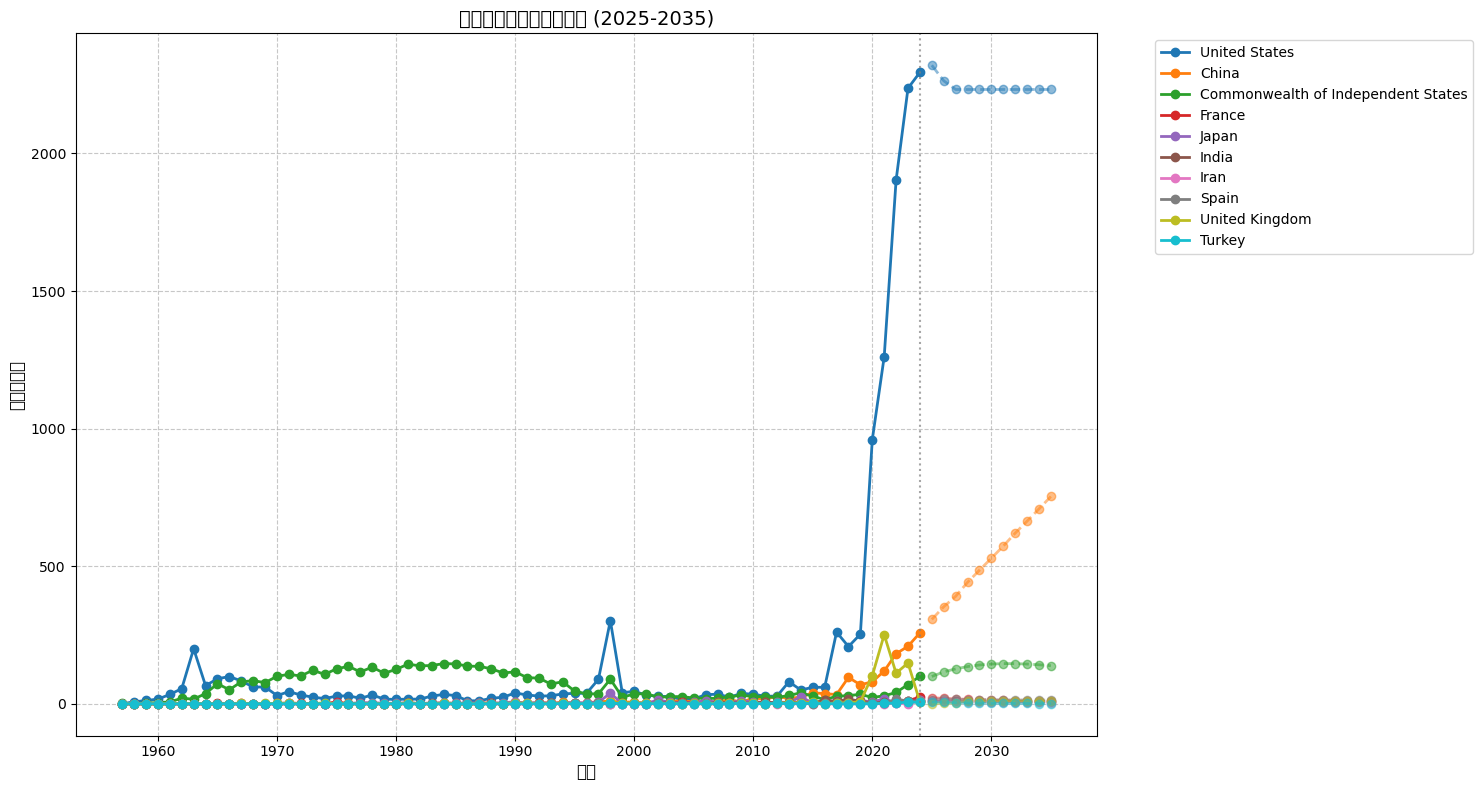


2024年发射量前10的国家：
                                 country  flow_launch
4728                       United States  2295.000000
857                                China   258.000000
936   Commonwealth of Independent States   100.102041
1489                              France    24.358870
2279                               Japan    12.000000
1805                               India    11.000000
1963                                Iran    10.000000
4017                               Spain     8.358870
4649                      United Kingdom     6.358870
4412                              Turkey     5.020408


In [10]:
# 导入必要的模块
import matplotlib.colors as mcolors

# 创建一个新的DataFrame来存储所有数据（历史+预测）
combined_data = df.copy()

# 逐年计算发射量预测
for year in range(2025, 2036):
    temp_data = pd.DataFrame(columns=['country', 'c_pred', 'd'])
    
    # 准备当年的预测数据
    for country in all_countries:
        c_pred = yearly_predictions[year][country]
        d = 1 / (tau + gamma)
        temp_data = pd.concat([temp_data, 
                             pd.DataFrame([{'country': country, 'c_pred': c_pred, 'd': d}])],
                             ignore_index=True)
    
    # 计算中间变量
    sum_d = temp_data['d'].sum()
    temp_data['lambda'] = temp_data['d'] / (1 / tau + sum_d)
    sum_lambda = temp_data['lambda'].sum()
    sum_lambda_c = (temp_data['lambda'] * temp_data['c_pred']).sum()
    
    # 为每个国家创建当年的记录
    year_data = []
    for country in temp_data['country']:
        row = temp_data[temp_data['country'] == country].iloc[0]
        d = row['d']
        c_pred = row['c_pred']
        
        # 发射量预测公式
        flow_launch_pred = d * ((1 - tau * S_prev) * (1 - sum_lambda) - c_pred + sum_lambda_c)
        flow_launch_pred = max(0, flow_launch_pred)  # 确保发射量非负
        
        # 创建当年该国家的完整记录
        year_data.append({
            'country': country,
            'year': year,
            'c_sim_median': c_pred,  # 将预测的c存为c_sim_median
            'flow_launch': flow_launch_pred  # 将预测的发射量存为flow_launch
        })
    
    # 将年度数据添加到combined_data
    year_df = pd.DataFrame(year_data)
    combined_data = pd.concat([combined_data, year_df], ignore_index=True)
    
    # 更新下一年的S_prev
    S_prev = combined_data[combined_data['year'] == year]['flow_launch'].sum()

# 按国家和年份排序
combined_data = combined_data.sort_values(['country', 'year'])

# 计算每个国家的累计发射量stock_launch
for country in combined_data['country'].unique():
    country_mask = combined_data['country'] == country
    combined_data.loc[country_mask, 'stock_launch'] = \
        combined_data.loc[country_mask, 'flow_launch'].cumsum()

# 计算全球年度总发射量
annual_totals = combined_data.groupby('year')['flow_launch'].sum().reset_index()
annual_totals = annual_totals.rename(columns={'flow_launch': 'annual_launch_total'})

# 计算全球累计发射量
combined_data['X_total_cum'] = combined_data.groupby('year')['stock_launch'].transform('sum')

# 将年度总发射量合并回主数据框
combined_data = combined_data.merge(annual_totals, on='year', how='left')

# 保存更新后的数据
combined_data.to_csv(f"{output_dir}major_player_data_with_predictions.csv", index=False)

# 获取2024年发射量前10的国家
top_10_countries = combined_data[combined_data['year'] == 2024].groupby('country')['flow_launch'].sum().nlargest(10).index

# 绘制预测结果（只展示前10国家）
plt.figure(figsize=(15, 8))
for country in top_10_countries:
    country_data = combined_data[combined_data['country'] == country]
    
    # 分隔2024年及之前的数据（实际数据）
    actual_data = country_data[country_data['year'] <= 2024]
    # 分隔2025年及之后的数据（预测数据）
    pred_data = country_data[country_data['year'] > 2024]
    
    # 使用深色显示实际数据
    plt.plot(actual_data['year'], actual_data['flow_launch'], 
             label=country, marker='o', linewidth=2)
    
    # 获取当前国家线条的颜色，然后使用相同但更浅的颜色显示预测数据
    line_color = plt.gca().lines[-1].get_color()
    lighter_color = mcolors.to_rgba(line_color, alpha=0.5)  # 使用透明度使颜色变浅
    
    # 使用浅色和虚线显示预测数据
    plt.plot(pred_data['year'], pred_data['flow_launch'], 
             color=lighter_color, marker='o', linestyle='--', linewidth=2)

plt.title('主要航天国家发射量预测 (2025-2035)', fontsize=14)
plt.xlabel('年份', fontsize=12)
plt.ylabel('预测发射量', fontsize=12)
plt.axvline(x=2024, color='gray', linestyle=':', alpha=0.7)  # 在2024年添加垂直分隔线
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

# 输出2024年发射量前10的国家及其发射量
top_10_summary = combined_data[
    (combined_data['year'] == 2024) & 
    (combined_data['country'].isin(top_10_countries))
].sort_values('flow_launch', ascending=False)

print("\n2024年发射量前10的国家：")
print(top_10_summary[['country', 'flow_launch']])

In [11]:
# 定义计算基尼系数的函数
def calculate_gini(data):
    # 将数据排序
    sorted_data = np.sort(data)
    n = len(data)
    # 计算洛伦兹曲线下的面积
    index = np.arange(1, n + 1)
    return ((2 * index - n - 1) * sorted_data).sum() / (n * sorted_data.sum())

# 创建DataFrame来存储每年的基尼系数
gini_coefficients = pd.DataFrame(columns=['year', 'flow_gini', 'stock_gini'])

# 计算每年的基尼系数
for year in combined_data['year'].unique():
    year_data = combined_data[combined_data['year'] == year]
    
    # 计算流量的基尼系数
    flow_gini = calculate_gini(year_data['flow_launch'].values)
    
    # 计算存量的基尼系数
    stock_gini = calculate_gini(year_data['stock_launch'].values)
    
    # 添加到结果DataFrame
    gini_coefficients = pd.concat([gini_coefficients,
                                 pd.DataFrame({'year': [year],
                                             'flow_gini': [flow_gini],
                                             'stock_gini': [stock_gini]})],
                                ignore_index=True)

# 定义计算基尼系数的函数
def calculate_gini(data):
    # 将数据排序
    sorted_data = np.sort(data)
    n = len(data)
    # 计算洛伦兹曲线下的面积
    index = np.arange(1, n + 1)
    return ((2 * index - n - 1) * sorted_data).sum() / (n * sorted_data.sum())

# 创建DataFrame来存储每年的基尼系数
gini_coefficients = pd.DataFrame(columns=['year', 'flow_gini', 'stock_gini'])

# 计算每年的基尼系数
for year in combined_data['year'].unique():
    year_data = combined_data[combined_data['year'] == year]
    
    # 计算流量的基尼系数
    flow_gini = calculate_gini(year_data['flow_launch'].values)
    
    # 计算存量的基尼系数
    stock_gini = calculate_gini(year_data['stock_launch'].values)
    
    # 添加到结果DataFrame
    gini_coefficients = pd.concat([gini_coefficients,
                                 pd.DataFrame({'year': [year],
                                             'flow_gini': [flow_gini],
                                             'stock_gini': [stock_gini]})],
                                ignore_index=True)





数据年份范围: 1957 至 2035
包含的国家: ['Algeria' 'Angola' 'Argentina' 'Australia' 'Bangladesh' 'Belgium'
 'Brazil' 'Bulgaria' 'Canada' 'Chile' 'China'
 'Commonwealth of Independent States' 'Croatia' 'Czech Republic' 'Denmark'
 'Egypt' 'Estonia' 'Finland' 'France' 'Germany' 'Greece' 'Hungary' 'India'
 'Indonesia' 'Iran' 'Iraq' 'Israel' 'Italy' 'Japan' 'Latvia' 'Lithuania'
 'Luxembourg' 'Malaysia' 'Morocco' 'Netherlands' 'New Zealand'
 'North Korea' 'Norway' 'Pakistan' 'Peru' 'Philippines' 'Poland'
 'Portugal' 'Qatar' 'Saudi Arabia' 'Singapore' 'Slovakia' 'Slovenia'
 'South Africa' 'South Korea' 'Spain' 'Sweden' 'Switzerland' 'Taiwan'
 'Thailand' 'Turkey' 'Ukraine' 'United Arab Emirates' 'United Kingdom'
 'United States' 'Uruguay']
预测年份数据检查: [2025 2026 2027 2028 2029 2030 2031 2032 2033 2034 2035]


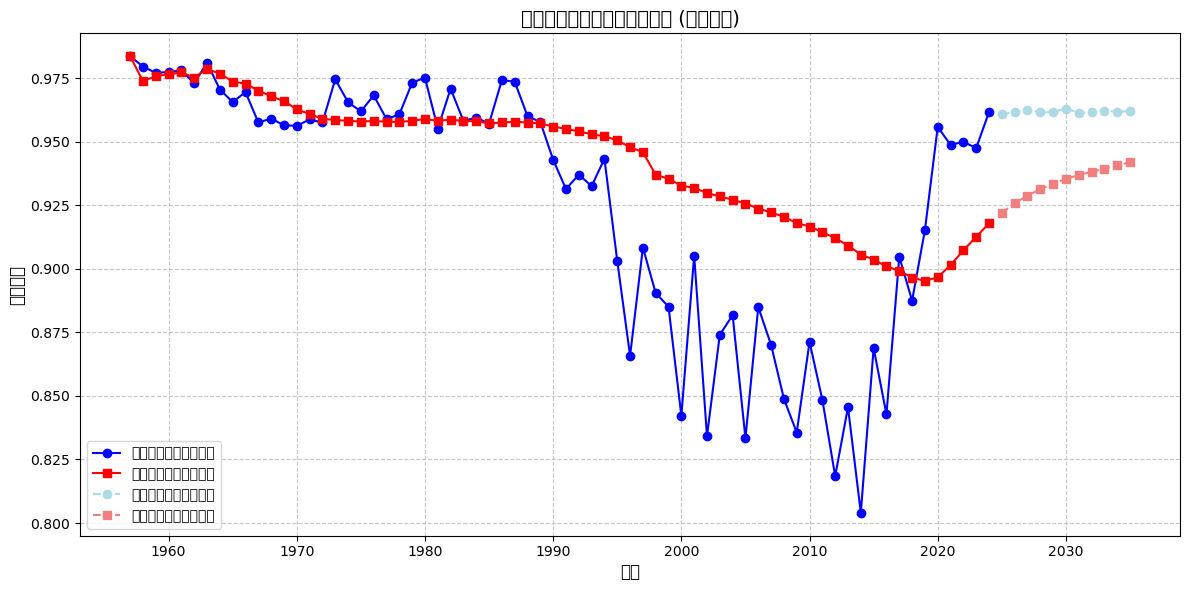

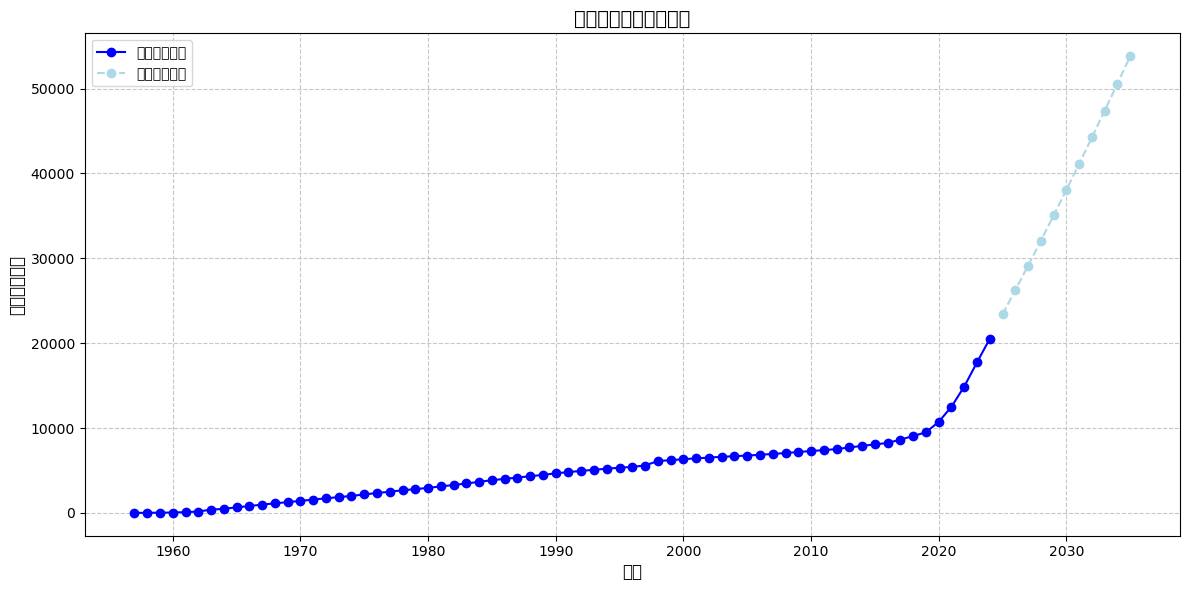

2024年发射量前10的国家: ['United States', 'Commonwealth of Independent States', 'China', 'United Kingdom', 'Japan', 'India', 'France', 'Germany', 'Canada', 'Italy']


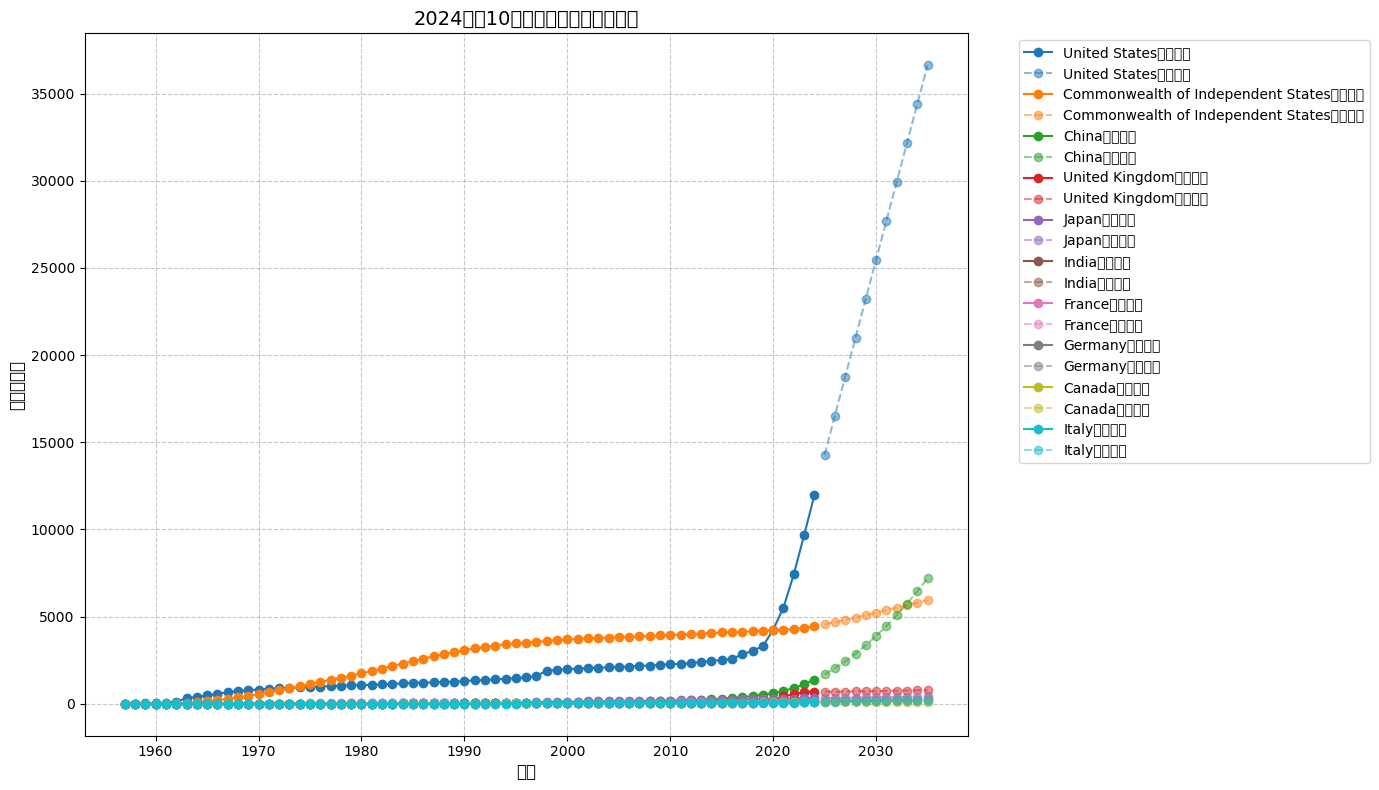

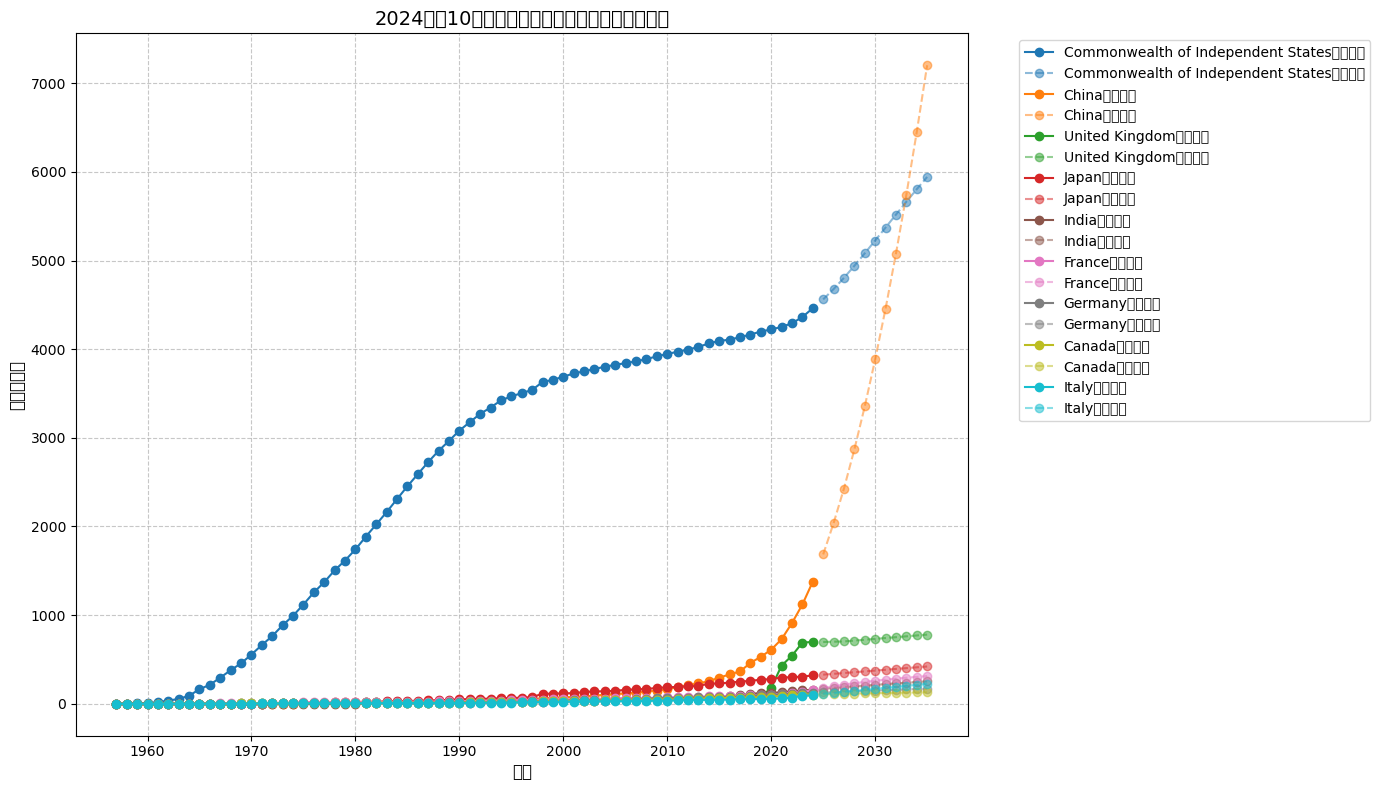

In [12]:
# 设置中文字体
import matplotlib.pyplot as plt
import matplotlib as mpl
import pandas as pd
import numpy as np

# 首先设置中文字体
mpl.rcParams['font.sans-serif'] = ['SimHei', 'Arial Unicode MS', 'DejaVu Sans', 'sans-serif']
mpl.rcParams['axes.unicode_minus'] = False

# 重新读取包含预测数据的CSV文件
df = pd.read_csv(f"{output_dir}major_player_data_with_predictions.csv")


# 打印数据检查
print("数据年份范围:", df['year'].min(), "至", df['year'].max())
print("包含的国家:", df['country'].unique())
print("预测年份数据检查:", df[df['year'] > 2024]['year'].unique())

# 1. 基尼系数图
# 首先需要计算每年的基尼系数
def calculate_gini(data):
    # 确保数据是非负的
    data = np.array(data)
    data = data[data >= 0]
    
    # 如果数据全为0或只有一个国家，则基尼系数为0
    if len(data) <= 1 or np.sum(data) == 0:
        return 0
    
    # 排序数据
    sorted_data = np.sort(data)
    n = len(sorted_data)
    
    # 计算基尼系数
    index = np.arange(1, n + 1)
    return ((2 * index - n - 1) * sorted_data).sum() / (n * sorted_data.sum())

# 创建DataFrame来存储每年的基尼系数
gini_coefficients = pd.DataFrame(columns=['year', 'flow_gini', 'stock_gini'])

# 计算每年的基尼系数
for year in df['year'].unique():
    year_data = df[df['year'] == year]
    
    # 计算流量的基尼系数 (flow_launch)
    flow_gini = calculate_gini(year_data['flow_launch'].values)
    
    # 计算存量的基尼系数 (stock_launch)
    stock_gini = calculate_gini(year_data['stock_launch'].values)
    
    # 添加到结果DataFrame
    gini_coefficients = pd.concat([gini_coefficients,
                                 pd.DataFrame({'year': [year],
                                             'flow_gini': [flow_gini],
                                             'stock_gini': [stock_gini]})],
                                ignore_index=True)

# 绘制基尼系数图
plt.figure(figsize=(12, 6))
mask_actual = gini_coefficients['year'] <= 2024
mask_pred = gini_coefficients['year'] > 2024

# 绘制实际数据（实线）
plt.plot(gini_coefficients.loc[mask_actual, 'year'], 
         gini_coefficients.loc[mask_actual, 'flow_gini'],
         label='发射量不平等（实际）', marker='o', linestyle='-', color='blue')
plt.plot(gini_coefficients.loc[mask_actual, 'year'],
         gini_coefficients.loc[mask_actual, 'stock_gini'],
         label='累计量不平等（实际）', marker='s', linestyle='-', color='red')

# 绘制预测数据（虚线）
plt.plot(gini_coefficients.loc[mask_pred, 'year'],
         gini_coefficients.loc[mask_pred, 'flow_gini'],
         label='发射量不平等（预测）', marker='o', linestyle='--', color='lightblue')
plt.plot(gini_coefficients.loc[mask_pred, 'year'],
         gini_coefficients.loc[mask_pred, 'stock_gini'],
         label='累计量不平等（预测）', marker='s', linestyle='--', color='lightcoral')

plt.title('全球航天发射不平等程度变化 (基尼系数)', fontsize=14)
plt.xlabel('年份', fontsize=12)
plt.ylabel('基尼系数', fontsize=12)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

# 2. 全球发射总量图
plt.figure(figsize=(12, 6))

# 计算每年的总发射量
yearly_totals = df.groupby('year')['flow_launch'].sum().reset_index()
yearly_totals['cum_launch'] = yearly_totals['flow_launch'].cumsum()

mask_actual = yearly_totals['year'] <= 2024
mask_pred = yearly_totals['year'] > 2024

# 绘制实际数据
plt.plot(yearly_totals.loc[mask_actual, 'year'],
         yearly_totals.loc[mask_actual, 'cum_launch'],
         label='实际发射总量', marker='o', color='blue')

# 绘制预测数据
plt.plot(yearly_totals.loc[mask_pred, 'year'],
         yearly_totals.loc[mask_pred, 'cum_launch'],
         label='预测发射总量', marker='o', linestyle='--', color='lightblue')

plt.title('全球航天发射总量变化', fontsize=14)
plt.xlabel('年份', fontsize=12)
plt.ylabel('累计发射总量', fontsize=12)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

# 3. 前10国家累计发射量图
plt.figure(figsize=(14, 8))

# 获取2024年发射量前10的国家
top10_countries = df[df['year'] == 2024].nlargest(10, 'stock_launch')['country'].tolist()
print("2024年发射量前10的国家:", top10_countries)

# 生成颜色
colors = plt.cm.tab10(np.linspace(0, 1, len(top10_countries)))

# 为每个国家绘制累计发射量
for i, country in enumerate(top10_countries):
    country_data = df[df['country'] == country]
    
    # 分离实际和预测数据
    actual_data = country_data[country_data['year'] <= 2024]
    pred_data = country_data[country_data['year'] > 2024]
    
    # 绘制实际数据
    plt.plot(actual_data['year'], actual_data['stock_launch'],
             label=f'{country}（实际）', marker='o', color=colors[i])
    
    # 绘制预测数据
    if not pred_data.empty:
        plt.plot(pred_data['year'], pred_data['stock_launch'],
                 label=f'{country}（预测）', marker='o', linestyle='--',
                 color=colors[i], alpha=0.5)

plt.title('2024年前10大发射国累计发射量变化', fontsize=14)
plt.xlabel('年份', fontsize=12)
plt.ylabel('累计发射量', fontsize=12)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

# 4. 除美国外其他9个国家的累计发射量图
plt.figure(figsize=(14, 8))

# 获取除美国外的其他9个国家
other_countries = [country for country in top10_countries if country != 'United States']
colors = plt.cm.tab10(np.linspace(0, 1, len(other_countries)))

# 为每个国家绘制累计发射量
for i, country in enumerate(other_countries):
    country_data = df[df['country'] == country]
    
    # 分离实际和预测数据
    actual_data = country_data[country_data['year'] <= 2024]
    pred_data = country_data[country_data['year'] > 2024]
    
    # 绘制实际数据
    plt.plot(actual_data['year'], actual_data['stock_launch'],
             label=f'{country}（实际）', marker='o', color=colors[i])
    
    # 绘制预测数据
    if not pred_data.empty:
        plt.plot(pred_data['year'], pred_data['stock_launch'],
                 label=f'{country}（预测）', marker='o', linestyle='--',
                 color=colors[i], alpha=0.5)

plt.title('2024年前10大发射国（除美国外）累计发射量变化', fontsize=14)
plt.xlabel('年份', fontsize=12)
plt.ylabel('累计发射量', fontsize=12)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

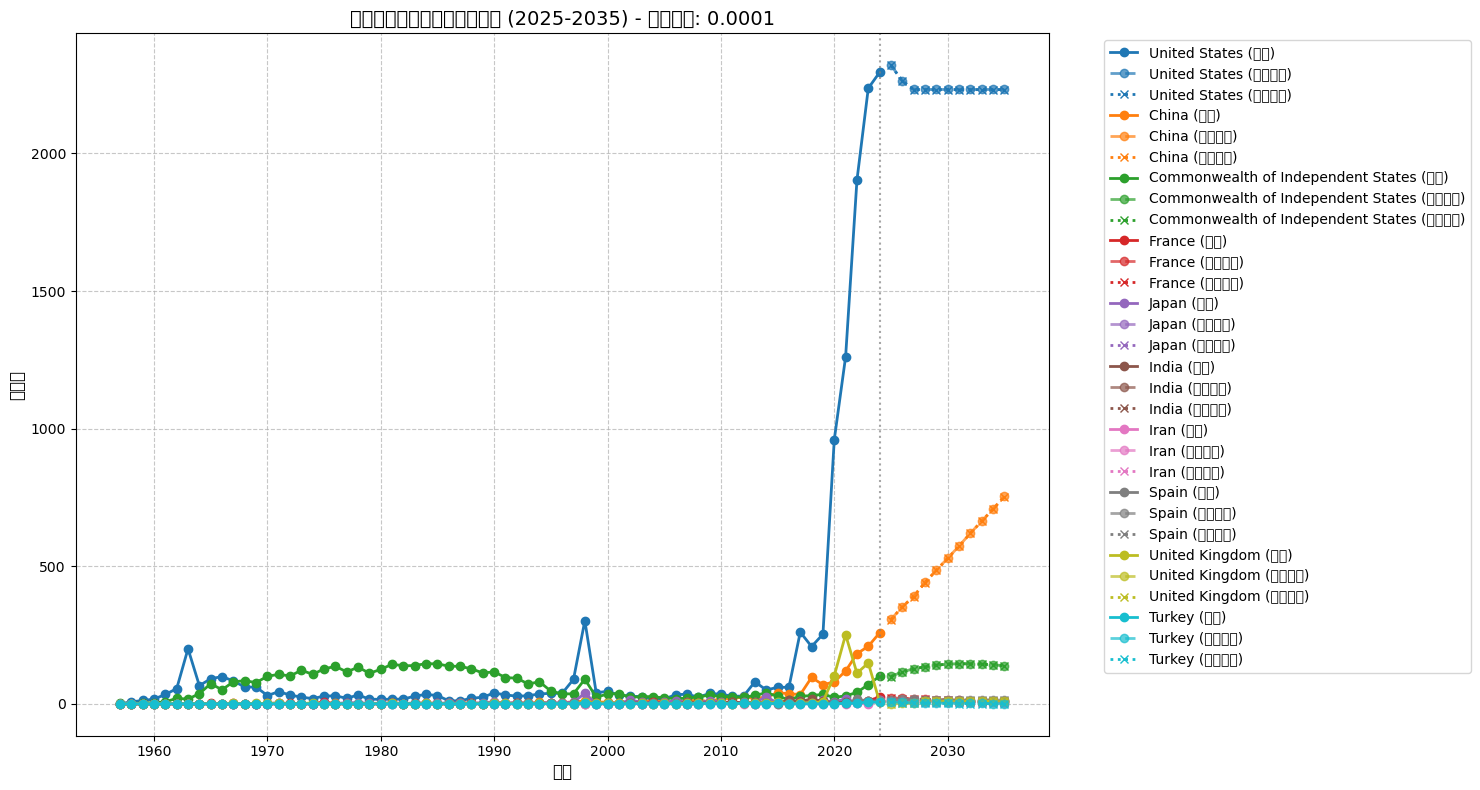

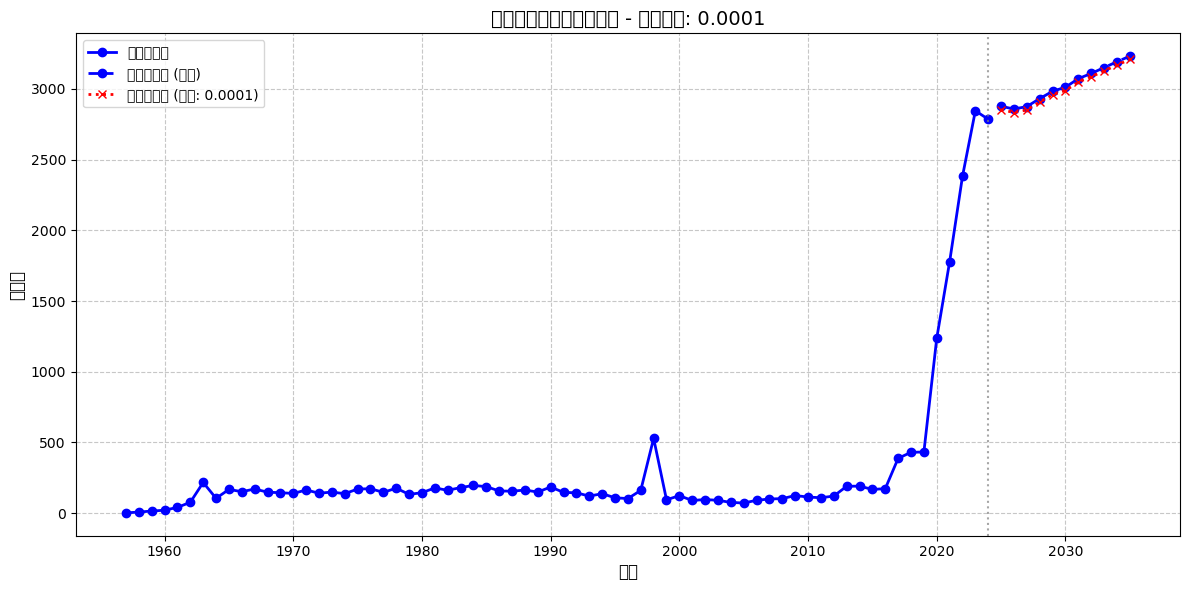


2024年发射量前10的国家：
                                 country  flow_launch
4728                       United States  2295.000000
857                                China   258.000000
936   Commonwealth of Independent States   100.102041
1489                              France    24.358870
2279                               Japan    12.000000
1805                               India    11.000000
1963                                Iran    10.000000
4017                               Spain     8.358870
4649                      United Kingdom     6.358870
4412                              Turkey     5.020408

2035年顶级航天国家发射量预测（税率: 0.0001）：
                                 country  flow_launch  flow_launch_tax  \
4739                       United States  2232.525939      2231.883984   
868                                China   753.447120       752.805165   
947   Commonwealth of Independent States   138.405936       137.763981   
4028                               Spain    13.583612        1

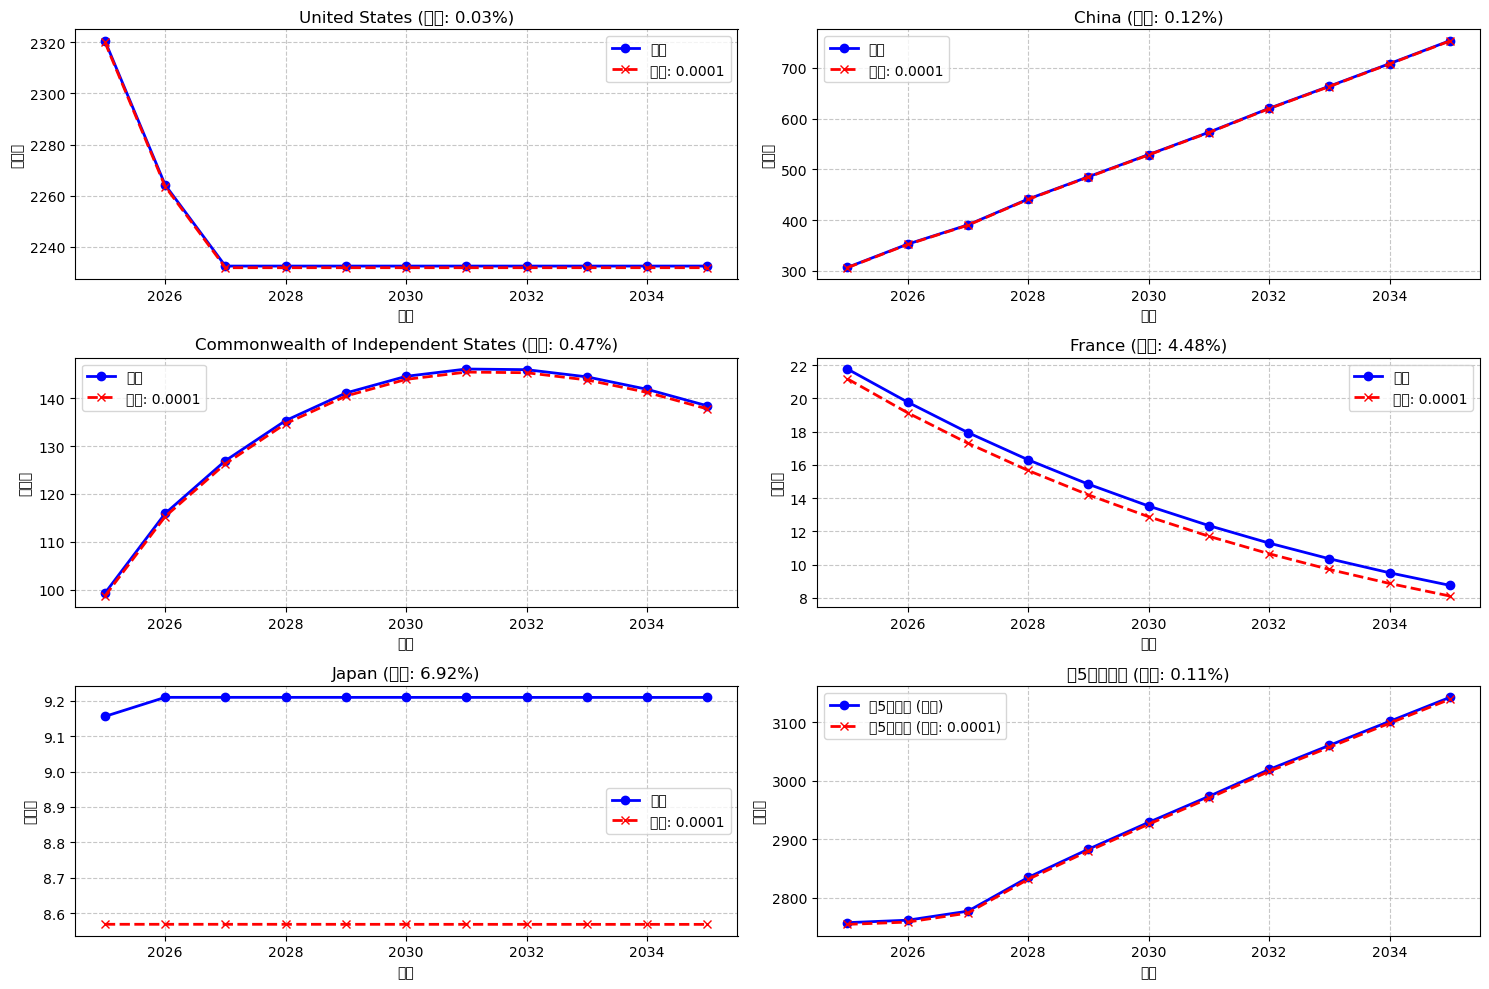


前5大航天国家在2025-2035年的发射变化:
United States:
  无税总发射量: 24677.58
  含税总发射量: 24670.57
  减排量: 7.01
  减排百分比: 0.03%
China:
  无税总发射量: 5824.21
  含税总发射量: 5817.20
  减排量: 7.01
  减排百分比: 0.12%
Commonwealth of Independent States:
  无税总发射量: 1479.92
  含税总发射量: 1472.91
  减排量: 7.01
  减排百分比: 0.47%
France:
  无税总发射量: 156.39
  含税总发射量: 149.39
  减排量: 7.01
  减排百分比: 4.48%
Japan:
  无税总发射量: 101.26
  含税总发射量: 94.25
  减排量: 7.01
  减排百分比: 6.92%

前5大航天国家年度详细发射量变化:
                               country  year  flow_launch  flow_launch_tax  \
11                               China  2025   306.740588       306.152618   
12                               China  2026   352.564037       351.922082   
13                               China  2027   390.496058       389.854104   
14                               China  2028   441.409203       440.767248   
15                               China  2029   485.348928       484.706973   
16                               China  2030   528.995407       528.353453   
17                      

In [24]:
# 固定税率模拟代码

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from tqdm import tqdm

# 定义全局参数
tau = 0.00000000005
gamma = 0.0001557692307692

# 定义输出目录
output_dir = "D:/Academic/RUC/Zheng/太空经济/CongestionTax/data/results/"

# 读取原始预测数据
df = pd.read_csv(f"{output_dir}major_player_data_with_predictions.csv")

# 设置固定税率
fixed_tax = 0.0001  # 这是一个示例值，可以根据需要调整

# 创建一个新的DataFrame来存储含税预测数据
tax_data = df.copy()

# 获取所有国家
all_countries = tax_data['country'].unique()

# 获取2024年的发射量总和作为S_prev的初始值
S_prev = tax_data[tax_data['year'] == 2024]['flow_launch'].sum()

# 添加含税后的成本列
tax_data['c_tax'] = tax_data['c_sim_median'] + fixed_tax

# 逐年计算含税后的发射量预测
for year in range(2025, 2036):
    # 准备当年的预测数据
    temp_data = pd.DataFrame(columns=['country', 'c_pred', 'd'])
    
    # 为每个国家准备预测数据
    for country in all_countries:
        # 获取不含税的预测成本
        c_pred_base = tax_data[(tax_data['country'] == country) & 
                              (tax_data['year'] == year)]['c_sim_median'].values[0]
        
        # 计算含税后的成本
        c_pred_tax = c_pred_base + fixed_tax
        
        # 计算d值
        d = 1 / (tau + gamma)
        
        # 添加到临时数据框
        temp_data = pd.concat([temp_data, 
                             pd.DataFrame([{'country': country, 'c_pred': c_pred_tax, 'd': d}])],
                             ignore_index=True)
    
    # 计算中间变量
    sum_d = temp_data['d'].sum()
    temp_data['lambda'] = temp_data['d'] / (1 / tau + sum_d)
    sum_lambda = temp_data['lambda'].sum()
    sum_lambda_c = (temp_data['lambda'] * temp_data['c_pred']).sum()
    
    # 为每个国家创建当年的记录
    year_data = []
    for country in temp_data['country']:
        row = temp_data[temp_data['country'] == country].iloc[0]
        d = row['d']
        c_pred = row['c_pred']
        
        # 发射量预测公式
        flow_launch_tax = d * ((1 - tau * S_prev) * (1 - sum_lambda) - c_pred + sum_lambda_c)
        flow_launch_tax = max(0, flow_launch_tax)  # 确保发射量非负
        
        # 更新税后发射量
        tax_data.loc[(tax_data['country'] == country) & 
                     (tax_data['year'] == year), 'flow_launch_tax'] = flow_launch_tax
    
    # 更新下一年的S_prev
    S_prev = tax_data[tax_data['year'] == year]['flow_launch_tax'].sum()

# 计算每个国家的税后累计发射量
for country in tax_data['country'].unique():
    country_mask = tax_data['country'] == country
    # 计算2024年及之前的累计发射量
    cumulative_2024 = tax_data[(country_mask) & (tax_data['year'] <= 2024)]['flow_launch'].cumsum()
    tax_data.loc[(country_mask) & (tax_data['year'] <= 2024), 'stock_launch_tax'] = cumulative_2024.values
    
    # 计算2025年及以后的累计发射量
    for year in range(2025, 2036):
        prev_stock = tax_data[(country_mask) & (tax_data['year'] == year-1)]['stock_launch_tax'].values[0]
        curr_flow = tax_data[(country_mask) & (tax_data['year'] == year)]['flow_launch_tax'].values[0]
        tax_data.loc[(country_mask) & (tax_data['year'] == year), 'stock_launch_tax'] = prev_stock + curr_flow

# 计算全球年度总发射量（税后）
annual_totals_tax = tax_data.groupby('year')['flow_launch_tax'].sum().reset_index()
annual_totals_tax = annual_totals_tax.rename(columns={'flow_launch_tax': 'annual_launch_total_tax'})

# 将年度总发射量合并回主数据框
tax_data = tax_data.merge(annual_totals_tax, on='year', how='left')

# 保存含税后的预测数据
tax_data.to_csv(f"{output_dir}major_player_data_with_tax_predictions.csv", index=False)

# 获取2024年发射量前10的国家
top_10_countries = tax_data[tax_data['year'] == 2024].groupby('country')['flow_launch'].sum().nlargest(10).index

# 绘制预测结果比较（只展示前10国家）
plt.figure(figsize=(15, 8))

for country in top_10_countries:
    country_data = tax_data[tax_data['country'] == country]
    
    # 分隔2024年及之前的数据（实际数据）
    actual_data = country_data[country_data['year'] <= 2024]
    # 分隔2025年及之后的数据（预测数据）
    pred_data = country_data[country_data['year'] > 2024]
    
    # 使用深色显示实际数据
    plt.plot(actual_data['year'], actual_data['flow_launch'], 
             label=f"{country} (实际)", marker='o', linewidth=2)
    
    # 获取当前国家线条的颜色
    line_color = plt.gca().lines[-1].get_color()
    
    # 使用相同但更浅的颜色显示无税预测
    lighter_color = mcolors.to_rgba(line_color, alpha=0.7)
    plt.plot(pred_data['year'], pred_data['flow_launch'], 
             label=f"{country} (预测无税)", color=lighter_color, marker='o', 
             linestyle='--', linewidth=2)
    
    # 使用相同颜色的点线显示含税预测
    plt.plot(pred_data['year'], pred_data['flow_launch_tax'], 
             label=f"{country} (预测含税)", color=line_color, marker='x', 
             linestyle=':', linewidth=2)

plt.title(f'主要航天国家发射量预测比较 (2025-2035) - 固定税率: {fixed_tax}', fontsize=14)
plt.xlabel('年份', fontsize=12)
plt.ylabel('发射量', fontsize=12)
plt.axvline(x=2024, color='gray', linestyle=':', alpha=0.7)  # 在2024年添加垂直分隔线
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.savefig(f"{output_dir}flow_launch_tax_comparison_tax_{fixed_tax}.png", dpi=300, bbox_inches='tight')
plt.show()

# 比较含税前后的全球总发射量
plt.figure(figsize=(12, 6))
yearly_totals = tax_data.groupby('year').agg({
    'flow_launch': 'sum',
    'flow_launch_tax': 'sum'
}).reset_index()

# 分隔实际数据和预测数据
actual_years = yearly_totals[yearly_totals['year'] <= 2024]
pred_years = yearly_totals[yearly_totals['year'] > 2024]

# 绘制实际数据
plt.plot(actual_years['year'], actual_years['flow_launch'], 
         label='历史发射量', marker='o', linewidth=2, color='blue')

# 绘制无税预测
plt.plot(pred_years['year'], pred_years['flow_launch'], 
         label='预测发射量 (无税)', marker='o', linewidth=2, 
         linestyle='--', color='blue')

# 绘制含税预测
plt.plot(pred_years['year'], pred_years['flow_launch_tax'], 
         label=f'预测发射量 (税率: {fixed_tax})', marker='x', 
         linewidth=2, linestyle=':', color='red')

plt.title(f'全球年度发射量预测比较 - 固定税率: {fixed_tax}', fontsize=14)
plt.xlabel('年份', fontsize=12)
plt.ylabel('发射量', fontsize=12)
plt.axvline(x=2024, color='gray', linestyle=':', alpha=0.7)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.savefig(f"{output_dir}global_flow_launch_tax_comparison_tax_{fixed_tax}.png", dpi=300, bbox_inches='tight')
plt.show()

# 输出2024年发射量前10的国家及其无税和含税发射量
top_10_summary = tax_data[
    (tax_data['year'] == 2024) & 
    (tax_data['country'].isin(top_10_countries))
].sort_values('flow_launch', ascending=False)

print("\n2024年发射量前10的国家：")
print(top_10_summary[['country', 'flow_launch']])

# 输出2035年预测中无税和含税的发射量对比
year_2035_comparison = tax_data[tax_data['year'] == 2035]
top_countries_2035 = year_2035_comparison.sort_values('flow_launch', ascending=False)['country'].head(10)

comparison_2035 = year_2035_comparison[
    year_2035_comparison['country'].isin(top_countries_2035)
].sort_values('flow_launch', ascending=False)

print(f"\n2035年顶级航天国家发射量预测（税率: {fixed_tax}）：")
print(comparison_2035[['country', 'flow_launch', 'flow_launch_tax', 'c_sim_median', 'c_tax']])

# 计算减排效果
total_no_tax = yearly_totals[yearly_totals['year'] > 2024]['flow_launch'].sum()
total_with_tax = yearly_totals[yearly_totals['year'] > 2024]['flow_launch_tax'].sum()
reduction = total_no_tax - total_with_tax
reduction_percentage = (reduction / total_no_tax) * 100

print(f"\n固定税率 {fixed_tax} 的减排效果:")
print(f"2025-2035年无税发射总量: {total_no_tax:.2f}")
print(f"2025-2035年含税发射总量: {total_with_tax:.2f}")
print(f"减排总量: {reduction:.2f}")
print(f"减排百分比: {reduction_percentage:.2f}%")

# 新增部分：显示发射量前5的国家在2025-2035年的发射变化
top_5_countries = tax_data[tax_data['year'] == 2024].groupby('country')['flow_launch'].sum().nlargest(5).index

# 创建一个新的图表
plt.figure(figsize=(15, 10))

# 为前5个国家创建子图
for i, country in enumerate(top_5_countries, 1):
    plt.subplot(3, 2, i)
    
    # 筛选该国家的数据
    country_data = tax_data[(tax_data['country'] == country) & (tax_data['year'] >= 2025) & (tax_data['year'] <= 2035)]
    
    # 绘制税前发射量
    plt.plot(country_data['year'], country_data['flow_launch'], 
             label='无税', marker='o', color='blue', linewidth=2)
    
    # 绘制税后发射量
    plt.plot(country_data['year'], country_data['flow_launch_tax'], 
             label=f'税率: {fixed_tax}', marker='x', color='red', 
             linestyle='--', linewidth=2)
    
    # 计算减排百分比
    total_no_tax_country = country_data['flow_launch'].sum()
    total_with_tax_country = country_data['flow_launch_tax'].sum()
    reduction_percentage_country = ((total_no_tax_country - total_with_tax_country) / total_no_tax_country) * 100
    
    plt.title(f'{country} (减排: {reduction_percentage_country:.2f}%)', fontsize=12)
    plt.xlabel('年份', fontsize=10)
    plt.ylabel('发射量', fontsize=10)
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.legend()

# 创建一个额外的子图显示所有5国的总和
plt.subplot(3, 2, 6)
top5_yearly = tax_data[tax_data['country'].isin(top_5_countries)].groupby('year').agg({
    'flow_launch': 'sum',
    'flow_launch_tax': 'sum'
}).reset_index()

top5_pred = top5_yearly[(top5_yearly['year'] >= 2025) & (top5_yearly['year'] <= 2035)]

# 绘制税前总和
plt.plot(top5_pred['year'], top5_pred['flow_launch'], 
         label='前5国总和 (无税)', marker='o', color='blue', linewidth=2)

# 绘制税后总和
plt.plot(top5_pred['year'], top5_pred['flow_launch_tax'], 
         label=f'前5国总和 (税率: {fixed_tax})', marker='x', color='red', 
         linestyle='--', linewidth=2)

# 计算前5国的减排百分比
top5_total_no_tax = top5_pred['flow_launch'].sum()
top5_total_with_tax = top5_pred['flow_launch_tax'].sum()
top5_reduction_percentage = ((top5_total_no_tax - top5_total_with_tax) / top5_total_no_tax) * 100

plt.title(f'前5国家总和 (减排: {top5_reduction_percentage:.2f}%)', fontsize=12)
plt.xlabel('年份', fontsize=10)
plt.ylabel('发射量', fontsize=10)
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend()

plt.tight_layout()
plt.savefig(f"{output_dir}top5_countries_tax_impact_{fixed_tax}.png", dpi=300, bbox_inches='tight')
plt.show()

# 打印前5国家在2025-2035年的发射总量变化
print("\n前5大航天国家在2025-2035年的发射变化:")
for country in top_5_countries:
    country_data = tax_data[(tax_data['country'] == country) & (tax_data['year'] >= 2025) & (tax_data['year'] <= 2035)]
    total_no_tax_country = country_data['flow_launch'].sum()
    total_with_tax_country = country_data['flow_launch_tax'].sum()
    reduction_country = total_no_tax_country - total_with_tax_country
    reduction_percentage_country = (reduction_country / total_no_tax_country) * 100
    
    print(f"{country}:")
    print(f"  无税总发射量: {total_no_tax_country:.2f}")
    print(f"  含税总发射量: {total_with_tax_country:.2f}")
    print(f"  减排量: {reduction_country:.2f}")
    print(f"  减排百分比: {reduction_percentage_country:.2f}%")

# 创建前5国家的税前税后发射量详细数据表
top5_details = pd.DataFrame(columns=['country', 'year', 'flow_launch', 'flow_launch_tax', 'reduction', 'reduction_percentage'])

for country in top_5_countries:
    country_data = tax_data[(tax_data['country'] == country) & (tax_data['year'] >= 2025) & (tax_data['year'] <= 2035)]
    
    for _, row in country_data.iterrows():
        reduction = row['flow_launch'] - row['flow_launch_tax']
        reduction_percentage = (reduction / row['flow_launch']) * 100 if row['flow_launch'] > 0 else 0
        
        new_row = {
            'country': country,
            'year': row['year'],
            'flow_launch': row['flow_launch'],
            'flow_launch_tax': row['flow_launch_tax'],
            'reduction': reduction,
            'reduction_percentage': reduction_percentage
        }
        
        top5_details = pd.concat([top5_details, pd.DataFrame([new_row])], ignore_index=True)

# 保存详细数据
top5_details.to_csv(f"{output_dir}top5_countries_tax_impact_details_{fixed_tax}.csv", index=False)

# 打印详细数据表格
print("\n前5大航天国家年度详细发射量变化:")
pd.set_option('display.max_rows', None)  # 显示所有行
print(top5_details.sort_values(['country', 'year']))

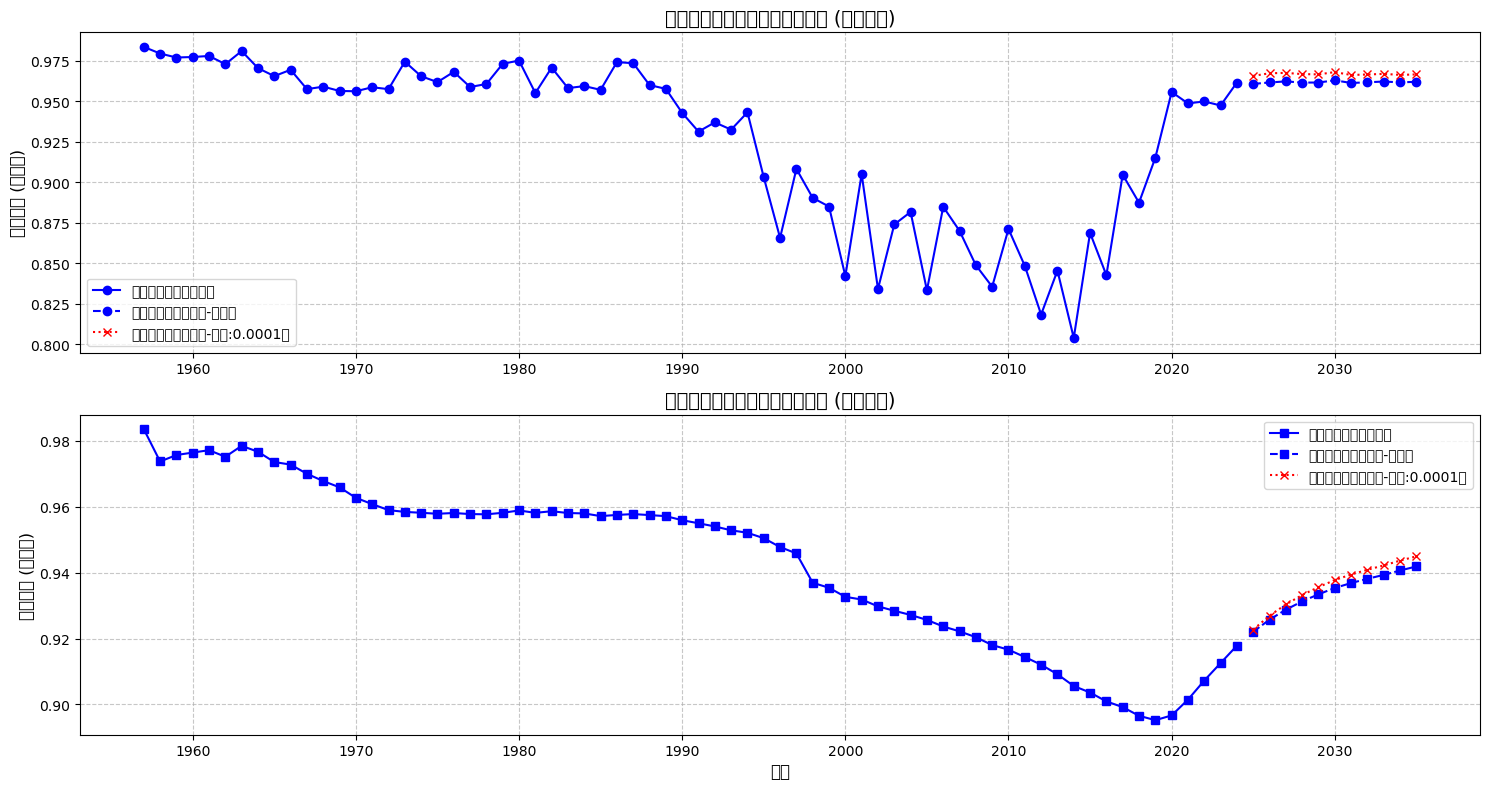


固定税率 0.0001 下的基尼系数变化:

年度发射量基尼系数:
    year  flow_gini_no_tax  flow_gini_with_tax
68  2025          0.960755            0.965696
69  2026          0.961643            0.967331
70  2027          0.962313            0.967552
71  2028          0.961577            0.966821
72  2029          0.961620            0.966641
73  2030          0.962969            0.968050
74  2031          0.961337            0.966268
75  2032          0.961740            0.966566
76  2033          0.962237            0.966952
77  2034          0.961704            0.966324
78  2035          0.962067            0.966604

累计发射量基尼系数:
    year  stock_gini_no_tax  stock_gini_with_tax
68  2025           0.922072             0.922716
69  2026           0.925746             0.926941
70  2027           0.928759             0.930362
71  2028           0.931291             0.933220
72  2029           0.933434             0.935618
73  2030           0.935363             0.937769
74  2031           0.936853             0.9394

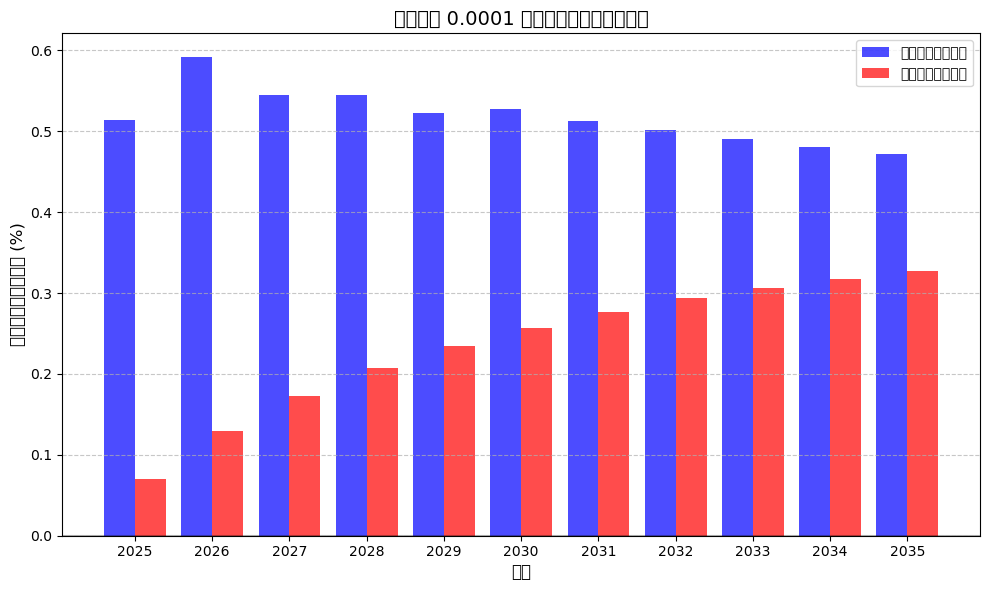

In [25]:
# 使用简单明确的方法计算基尼系数
def calculate_gini_simple(data):
    # 过滤掉NaN和负值，转换为Python原生列表
    filtered_data = []
    for val in data:
        if isinstance(val, (int, float)) and not np.isnan(val) and val >= 0:
            filtered_data.append(val)
    
    # 如果数据为空或只有一个值或全为0
    if len(filtered_data) <= 1 or sum(filtered_data) == 0:
        return 0.0
    
    # 排序数据
    sorted_data = sorted(filtered_data)
    n = len(sorted_data)
    
    # 使用基尼系数的定义公式计算
    cumulative_population = [i/n for i in range(1, n+1)]
    cumulative_wealth = [sum(sorted_data[:i])/sum(sorted_data) for i in range(1, n+1)]
    
    # 计算洛伦兹曲线下面积 (使用梯形积分)
    area = 0.0
    for i in range(n-1):
        area += 0.5 * (cumulative_population[i+1] - cumulative_population[i]) * (cumulative_wealth[i+1] + cumulative_wealth[i])
    
    # 基尼系数 = 1 - 2 * 洛伦兹曲线下面积
    return 1.0 - 2.0 * area

# 创建DataFrame来存储税前和税后的基尼系数
gini_comparison = pd.DataFrame(columns=['year', 'flow_gini_no_tax', 'stock_gini_no_tax', 
                                      'flow_gini_with_tax', 'stock_gini_with_tax'])

# 计算每年的基尼系数（税前和税后）
for year in tax_data['year'].unique():
    year_data = tax_data[tax_data['year'] == year]
    
    try:
        # 税前基尼系数计算
        flow_gini_no_tax = calculate_gini_simple(year_data['flow_launch'].tolist())
        stock_gini_no_tax = calculate_gini_simple(year_data['stock_launch'].tolist())
        
        # 对于2025年后的数据，计算税后基尼系数
        if year >= 2025:
            # 确保处理的列存在
            if 'flow_launch_tax' in year_data.columns:
                flow_gini_with_tax = calculate_gini_simple(year_data['flow_launch_tax'].tolist())
            else:
                flow_gini_with_tax = flow_gini_no_tax
                
            if 'stock_launch_tax' in year_data.columns:
                stock_gini_with_tax = calculate_gini_simple(year_data['stock_launch_tax'].tolist())
            else:
                stock_gini_with_tax = stock_gini_no_tax
        else:
            # 对于2024年及之前的数据，税前税后相同
            flow_gini_with_tax = flow_gini_no_tax
            stock_gini_with_tax = stock_gini_no_tax
        
        # 添加到结果DataFrame
        new_row = {
            'year': year,
            'flow_gini_no_tax': flow_gini_no_tax,
            'stock_gini_no_tax': stock_gini_no_tax,
            'flow_gini_with_tax': flow_gini_with_tax,
            'stock_gini_with_tax': stock_gini_with_tax
        }
        gini_comparison = pd.concat([gini_comparison, pd.DataFrame([new_row])], ignore_index=True)
    
    except Exception as e:
        print(f"计算{year}年的基尼系数时出错: {str(e)}")
        # 出错时填充0值
        new_row = {
            'year': year,
            'flow_gini_no_tax': 0.0,
            'stock_gini_no_tax': 0.0,
            'flow_gini_with_tax': 0.0,
            'stock_gini_with_tax': 0.0
        }
        gini_comparison = pd.concat([gini_comparison, pd.DataFrame([new_row])], ignore_index=True)

# 确保所有列都是数值型
numeric_cols = ['flow_gini_no_tax', 'stock_gini_no_tax', 'flow_gini_with_tax', 'stock_gini_with_tax']
for col in numeric_cols:
    gini_comparison[col] = pd.to_numeric(gini_comparison[col], errors='coerce').fillna(0)

# 按年份排序
gini_comparison = gini_comparison.sort_values('year').reset_index(drop=True)

# 绘制基尼系数对比图
plt.figure(figsize=(15, 8))

# 分割实际数据和预测数据
mask_actual = gini_comparison['year'] <= 2024
mask_pred = gini_comparison['year'] > 2024

# 1. 发射量基尼系数对比
plt.subplot(2, 1, 1)

# 绘制实际数据（实线）
plt.plot(gini_comparison.loc[mask_actual, 'year'], 
         gini_comparison.loc[mask_actual, 'flow_gini_no_tax'],
         label='发射量不平等（实际）', marker='o', linestyle='-', color='blue')

# 绘制预测数据（税前 - 虚线）
plt.plot(gini_comparison.loc[mask_pred, 'year'],
         gini_comparison.loc[mask_pred, 'flow_gini_no_tax'],
         label='发射量不平等（预测-无税）', marker='o', linestyle='--', color='blue')

# 绘制预测数据（税后 - 点线）
plt.plot(gini_comparison.loc[mask_pred, 'year'],
         gini_comparison.loc[mask_pred, 'flow_gini_with_tax'],
         label=f'发射量不平等（预测-税率:{fixed_tax}）', marker='x', linestyle=':', color='red')

plt.title('全球航天发射量不平等程度变化 (基尼系数)', fontsize=14)
plt.ylabel('基尼系数 (发射量)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend()

# 2. 存量基尼系数对比
plt.subplot(2, 1, 2)

# 绘制实际数据（实线）
plt.plot(gini_comparison.loc[mask_actual, 'year'],
         gini_comparison.loc[mask_actual, 'stock_gini_no_tax'],
         label='累计量不平等（实际）', marker='s', linestyle='-', color='blue')

# 绘制预测数据（税前 - 虚线）
plt.plot(gini_comparison.loc[mask_pred, 'year'],
         gini_comparison.loc[mask_pred, 'stock_gini_no_tax'],
         label='累计量不平等（预测-无税）', marker='s', linestyle='--', color='blue')

# 绘制预测数据（税后 - 点线）
plt.plot(gini_comparison.loc[mask_pred, 'year'],
         gini_comparison.loc[mask_pred, 'stock_gini_with_tax'],
         label=f'累计量不平等（预测-税率:{fixed_tax}）', marker='x', linestyle=':', color='red')

plt.title('全球航天累计量不平等程度变化 (基尼系数)', fontsize=14)
plt.xlabel('年份', fontsize=12)
plt.ylabel('基尼系数 (累计量)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend()

plt.tight_layout()
plt.savefig(f"{output_dir}gini_coefficient_comparison_tax_{fixed_tax}.png", dpi=300, bbox_inches='tight')
plt.show()

# 打印基尼系数变化数据
print(f"\n固定税率 {fixed_tax} 下的基尼系数变化:")
print("\n年度发射量基尼系数:")
print(gini_comparison[gini_comparison['year'] >= 2025][['year', 'flow_gini_no_tax', 'flow_gini_with_tax']])

print("\n累计发射量基尼系数:")
print(gini_comparison[gini_comparison['year'] >= 2025][['year', 'stock_gini_no_tax', 'stock_gini_with_tax']])

# 计算2035年的基尼系数变化
if 2035 in gini_comparison['year'].values:
    gini_2035 = gini_comparison[gini_comparison['year'] == 2035].iloc[0]
    
    # 安全计算变化率，避免除以零
    flow_gini_change = 0.0
    stock_gini_change = 0.0
    
    if gini_2035['flow_gini_no_tax'] > 0:
        flow_gini_change = ((gini_2035['flow_gini_with_tax'] - gini_2035['flow_gini_no_tax']) / 
                           gini_2035['flow_gini_no_tax'] * 100)
        
    if gini_2035['stock_gini_no_tax'] > 0:
        stock_gini_change = ((gini_2035['stock_gini_with_tax'] - gini_2035['stock_gini_no_tax']) / 
                            gini_2035['stock_gini_no_tax'] * 100)

    print(f"\n2035年基尼系数变化率:")
    print(f"发射量基尼系数变化率: {flow_gini_change:.2f}%")
    print(f"累计量基尼系数变化率: {stock_gini_change:.2f}%")

# 创建一个单独的图来比较不平等程度的变化
try:
    plt.figure(figsize=(10, 6))

    # 计算变化百分比 - 小心处理0值
    flow_change_pct = []
    stock_change_pct = []
    years = []

    for _, row in gini_comparison[gini_comparison['year'] >= 2025].iterrows():
        year = row['year']
        flow_no_tax = row['flow_gini_no_tax']
        flow_with_tax = row['flow_gini_with_tax']
        stock_no_tax = row['stock_gini_no_tax']
        stock_with_tax = row['stock_gini_with_tax']
        
        years.append(year)
        
        # 计算变化百分比，避免除以0
        if flow_no_tax > 0:
            flow_change = (flow_with_tax - flow_no_tax) / flow_no_tax * 100
        else:
            flow_change = 0
        flow_change_pct.append(flow_change)
        
        if stock_no_tax > 0:
            stock_change = (stock_with_tax - stock_no_tax) / stock_no_tax * 100
        else:
            stock_change = 0
        stock_change_pct.append(stock_change)

    # 绘制不平等变化百分比
    years = np.array(years)
    plt.bar(years - 0.2, flow_change_pct, width=0.4, color='blue', alpha=0.7, label='发射量不平等变化')
    plt.bar(years + 0.2, stock_change_pct, width=0.4, color='red', alpha=0.7, label='累计量不平等变化')

    plt.axhline(y=0, color='black', linestyle='-', alpha=0.3)
    plt.title(f'固定税率 {fixed_tax} 对航天不平等程度的影响', fontsize=14)
    plt.xlabel('年份', fontsize=12)
    plt.ylabel('基尼系数变化百分比 (%)', fontsize=12)
    plt.xticks(years)
    plt.grid(True, linestyle='--', alpha=0.7, axis='y')
    plt.legend()

    plt.tight_layout()
    plt.savefig(f"{output_dir}gini_change_percentage_tax_{fixed_tax}.png", dpi=300, bbox_inches='tight')
    plt.show()
except Exception as e:
    print(f"绘制基尼系数变化百分比图表时出错: {str(e)}")


开始模拟税率 0 的情况

开始模拟税率 0.001 的情况

开始模拟税率 0.005 的情况

开始模拟税率 0.01 的情况


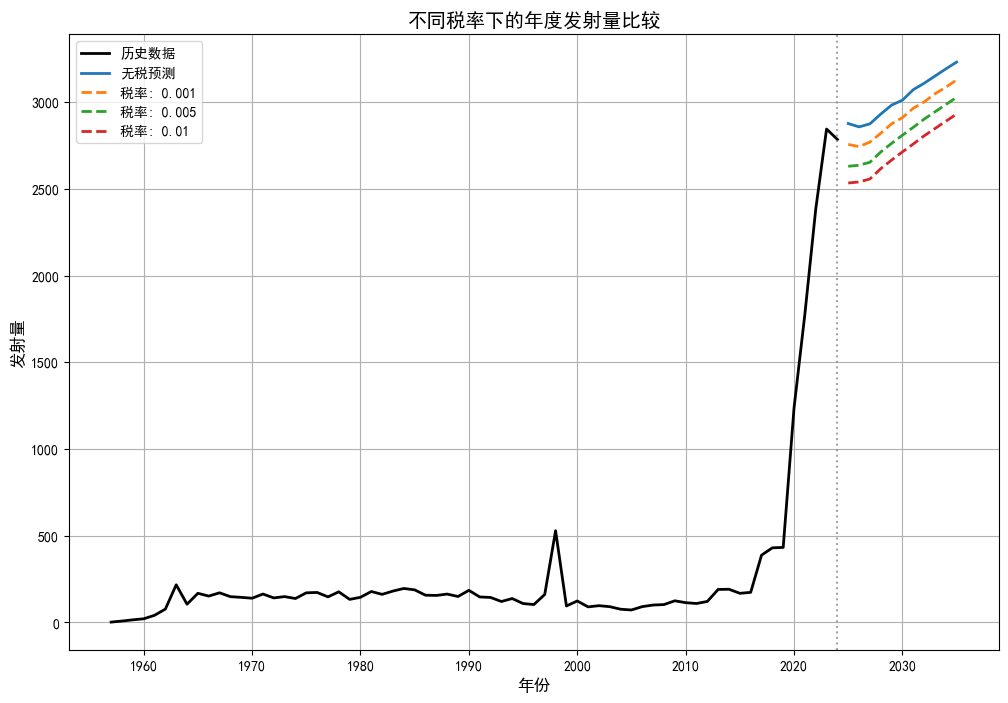

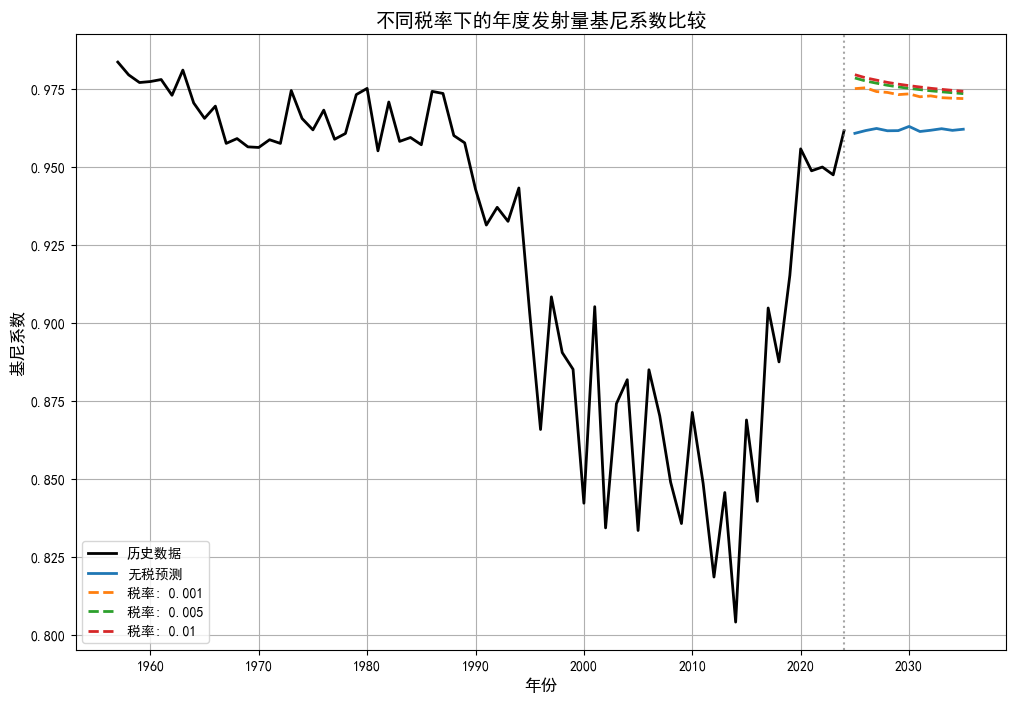

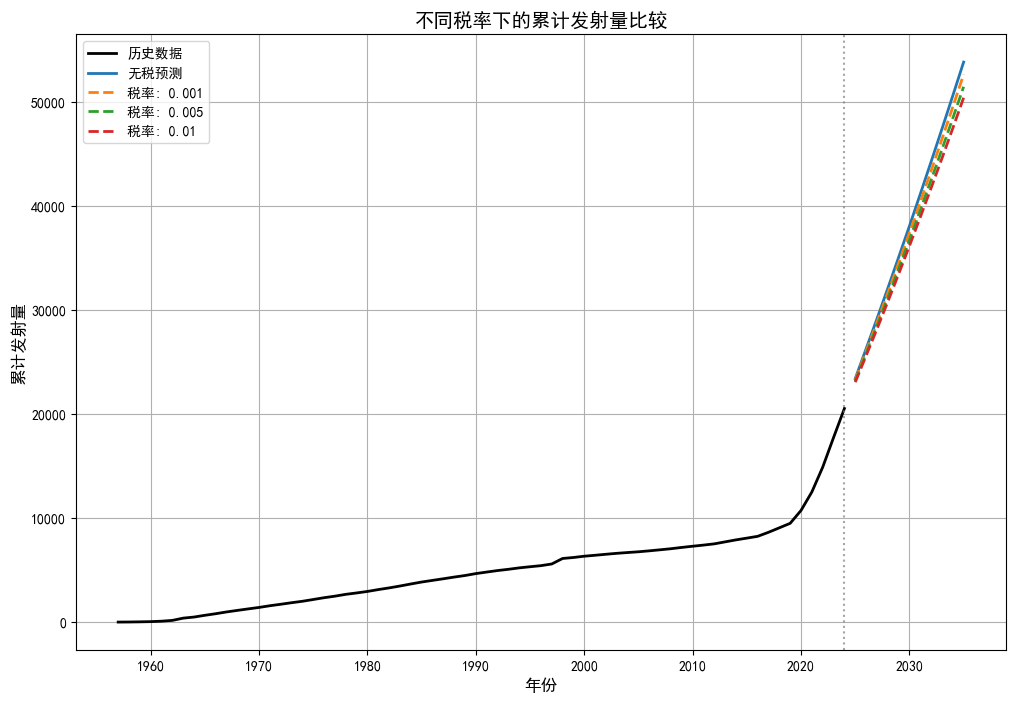

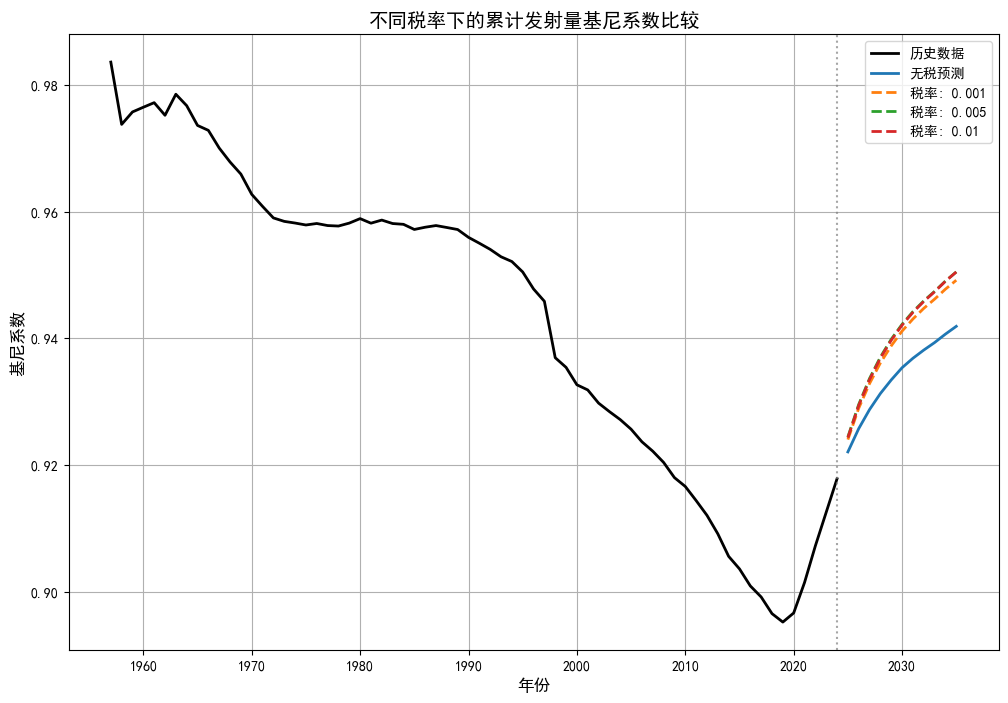


税率 0 的模拟结果 (2025-2035年):
总发射量: 33292.22

税率 0.001 的模拟结果 (2025-2035年):
总发射量: 32108.05
减排量: 1184.17
减排百分比: 3.56%

税率 0.005 的模拟结果 (2025-2035年):
总发射量: 30922.63
减排量: 2369.58
减排百分比: 7.12%

税率 0.01 的模拟结果 (2025-2035年):
总发射量: 29863.39
减排量: 3428.82
减排百分比: 10.30%


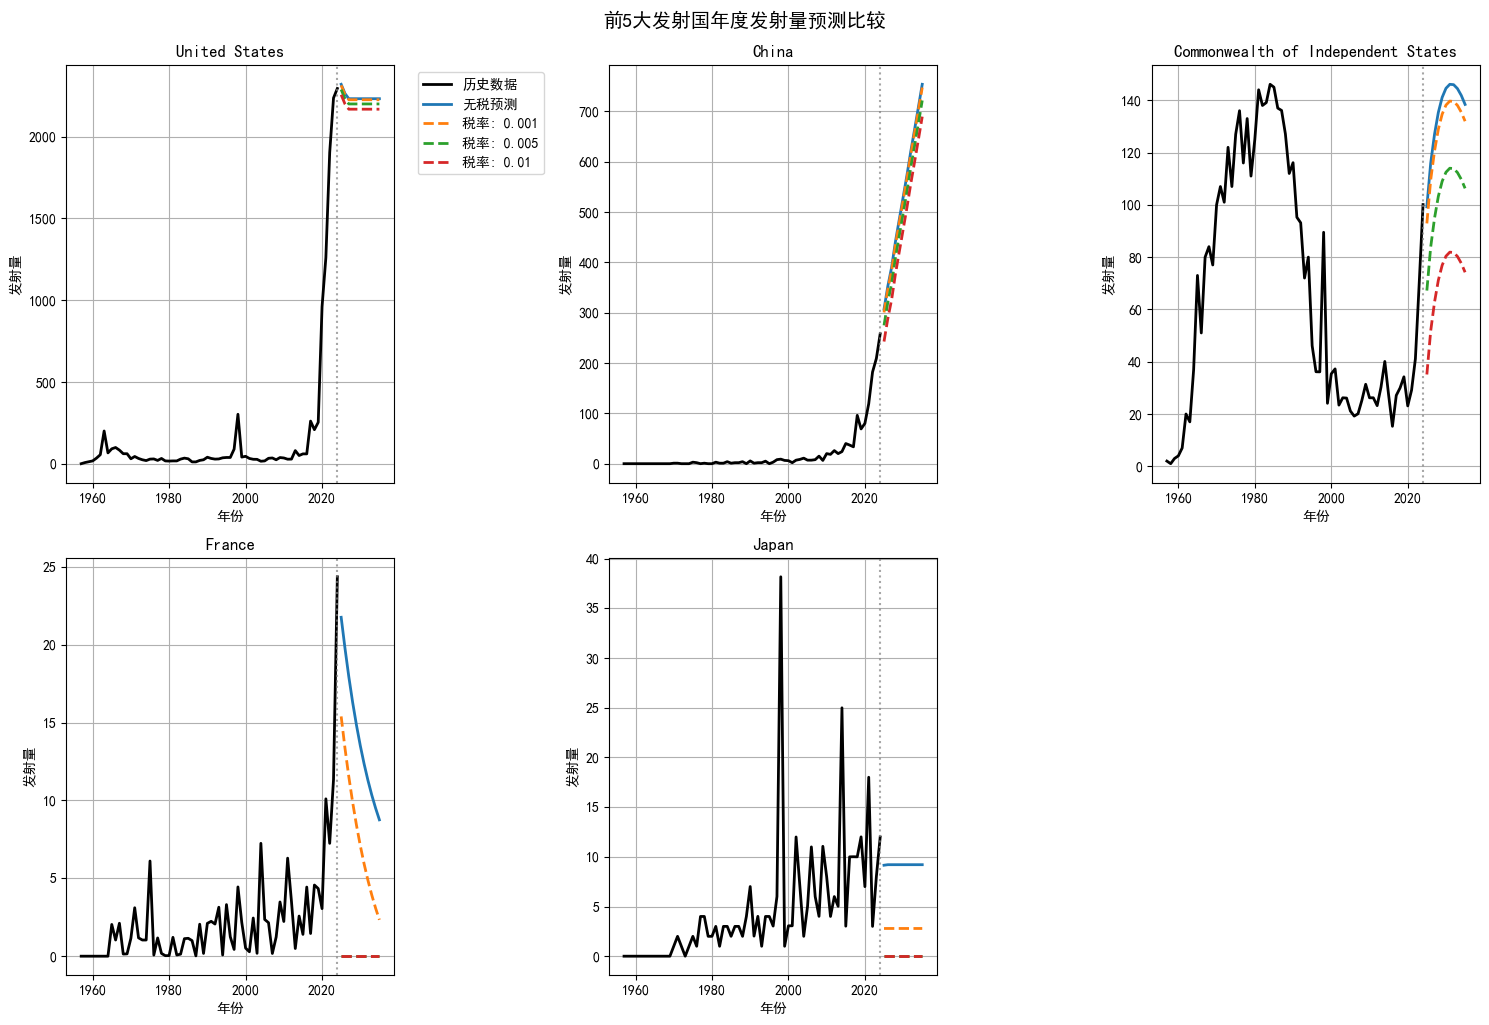

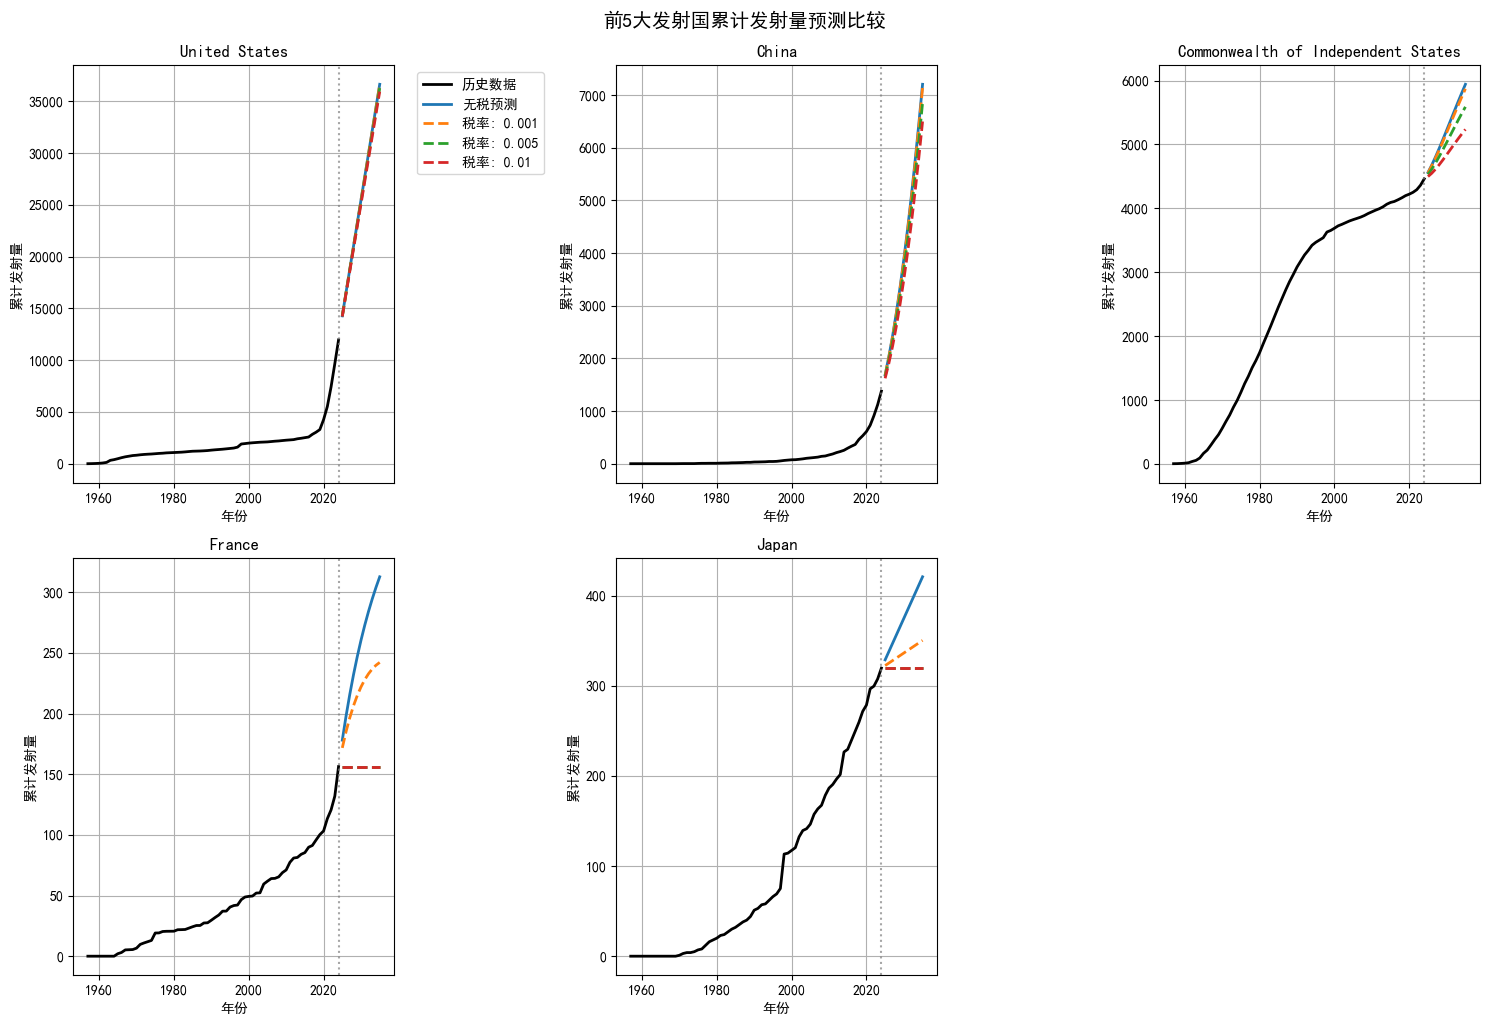


前5大发射国2024年发射量：
United States: 2295.00
China: 258.00
Commonwealth of Independent States: 100.10
France: 24.36
Japan: 12.00

所有结果数据已保存到输出目录。


In [9]:
# 固定税率模拟代码

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from tqdm import tqdm

# 设置中文字体
plt.rcParams['font.sans-serif'] = ['SimHei']  # 用来正常显示中文标签
plt.rcParams['axes.unicode_minus'] = False  # 用来正常显示负号

# 定义全局参数
tau = 0.00000000005
gamma = 0.0001557692307692

# 定义输出目录
output_dir = "D:/Academic/RUC/Zheng/太空经济/CongestionTax/data/results/"

# 定义不同的税率
tax_rates = [0, 0.001, 0.005, 0.01]
tax_results = {}

# 使用简单明确的方法计算基尼系数
def calculate_gini_simple(data):
    # 过滤掉NaN和负值，转换为Python原生列表
    filtered_data = []
    for val in data:
        if isinstance(val, (int, float)) and not np.isnan(val) and val >= 0:
            filtered_data.append(float(val))
    
    # 如果数据为空或只有一个值或全为0
    if len(filtered_data) <= 1 or sum(filtered_data) == 0:
        return 0.0
    
    # 排序数据
    sorted_data = sorted(filtered_data)
    n = len(sorted_data)
    
    # 使用基尼系数的定义公式计算
    cumulative_population = [i/n for i in range(1, n+1)]
    cumulative_wealth = [sum(sorted_data[:i])/sum(sorted_data) for i in range(1, n+1)]
    
    # 计算洛伦兹曲线下面积 (使用梯形积分)
    area = 0.0
    for i in range(n-1):
        area += 0.5 * (cumulative_population[i+1] - cumulative_population[i]) * (cumulative_wealth[i+1] + cumulative_wealth[i])
    
    # 基尼系数 = 1 - 2 * 洛伦兹曲线下面积
    return 1.0 - 2.0 * area

# 对每个税率进行模拟
for fixed_tax in tax_rates:
    print(f"\n开始模拟税率 {fixed_tax} 的情况")
    
    # 读取原始预测数据
    df = pd.read_csv(f"{output_dir}major_player_data_with_predictions.csv")
    
    # 创建一个新的DataFrame来存储含税预测数据
    tax_data = df.copy()
    
    # 2024年及之前的数据保持不变
    tax_data.loc[tax_data['year'] <= 2024, 'flow_launch_tax'] = tax_data.loc[tax_data['year'] <= 2024, 'flow_launch']
    tax_data.loc[tax_data['year'] <= 2024, 'stock_launch_tax'] = tax_data.loc[tax_data['year'] <= 2024, 'stock_launch']
    
    if fixed_tax > 0:  # 只对非零税率进行模拟计算
        # 获取所有国家
        all_countries = tax_data['country'].unique()
        
        # 获取2024年的发射量总和作为S_prev的初始值
        S_prev = tax_data[tax_data['year'] == 2024]['flow_launch'].sum()
        
        # 添加含税后的成本列
        tax_data['c_tax'] = tax_data['c_sim_median'] + fixed_tax
        
        # 逐年计算含税后的发射量预测
        for year in range(2025, 2036):
            # 准备当年的预测数据
            temp_data = pd.DataFrame(columns=['country', 'c_pred', 'd'])
            
            # 为每个国家准备预测数据
            for country in all_countries:
                c_pred_base = tax_data[(tax_data['country'] == country) & 
                                     (tax_data['year'] == year)]['c_sim_median'].values[0]
                c_pred_tax = c_pred_base + fixed_tax
                d = 1 / (tau + gamma)
                temp_data = pd.concat([temp_data, 
                                     pd.DataFrame([{'country': country, 'c_pred': c_pred_tax, 'd': d}])],
                                     ignore_index=True)
            
            # 计算中间变量
            sum_d = temp_data['d'].sum()
            temp_data['lambda'] = temp_data['d'] / (1 / tau + sum_d)
            sum_lambda = temp_data['lambda'].sum()
            sum_lambda_c = (temp_data['lambda'] * temp_data['c_pred']).sum()
            
            # 为每个国家创建当年的记录
            for country in temp_data['country']:
                row = temp_data[temp_data['country'] == country].iloc[0]
                d = row['d']
                c_pred = row['c_pred']
                
                # 发射量预测公式
                flow_launch_tax = d * ((1 - tau * S_prev) * (1 - sum_lambda) - c_pred + sum_lambda_c)
                flow_launch_tax = max(0, flow_launch_tax)  # 确保发射量非负
                
                # 更新税后发射量
                tax_data.loc[(tax_data['country'] == country) & 
                             (tax_data['year'] == year), 'flow_launch_tax'] = flow_launch_tax
            
            # 更新下一年的S_prev
            S_prev = tax_data[tax_data['year'] == year]['flow_launch_tax'].sum()

        # 计算每个国家的税后累计发射量
        for country in tax_data['country'].unique():
            country_mask = tax_data['country'] == country
            # 计算2024年及之前的累计发射量
            cumulative_2024 = tax_data[(country_mask) & (tax_data['year'] <= 2024)]['flow_launch'].cumsum()
            tax_data.loc[(country_mask) & (tax_data['year'] <= 2024), 'stock_launch_tax'] = cumulative_2024.values
            
            # 计算2025年及以后的累计发射量
            for year in range(2025, 2036):
                prev_stock = tax_data[(country_mask) & (tax_data['year'] == year-1)]['stock_launch_tax'].values[0]
                curr_flow = tax_data[(country_mask) & (tax_data['year'] == year)]['flow_launch_tax'].values[0]
                tax_data.loc[(country_mask) & (tax_data['year'] == year), 'stock_launch_tax'] = prev_stock + curr_flow

    # 计算基尼系数
    gini_comparison = pd.DataFrame(columns=['year', 'flow_gini_no_tax', 'stock_gini_no_tax', 
                                          'flow_gini_with_tax', 'stock_gini_with_tax'])

    # 计算每年的基尼系数（税前和税后）
    for year in tax_data['year'].unique():
        year_data = tax_data[tax_data['year'] == year]
        
        try:
            # 税前基尼系数计算
            flow_gini_no_tax = calculate_gini_simple(year_data['flow_launch'].tolist())
            stock_gini_no_tax = calculate_gini_simple(year_data['stock_launch'].tolist())
            
            # 对于2025年后的数据，计算税后基尼系数
            if year >= 2025:
                flow_gini_with_tax = calculate_gini_simple(year_data['flow_launch_tax'].tolist())
                stock_gini_with_tax = calculate_gini_simple(year_data['stock_launch_tax'].tolist())
            else:
                # 对于2024年及之前的数据，税前税后相同
                flow_gini_with_tax = flow_gini_no_tax
                stock_gini_with_tax = stock_gini_no_tax
            
            # 添加到结果DataFrame
            new_row = {
                'year': year,
                'flow_gini_no_tax': flow_gini_no_tax,
                'stock_gini_no_tax': stock_gini_no_tax,
                'flow_gini_with_tax': flow_gini_with_tax,
                'stock_gini_with_tax': stock_gini_with_tax
            }
            gini_comparison = pd.concat([gini_comparison, pd.DataFrame([new_row])], ignore_index=True)
        
        except Exception as e:
            print(f"计算{year}年的基尼系数时出错: {str(e)}")
            # 出错时填充0值
            new_row = {
                'year': year,
                'flow_gini_no_tax': 0.0,
                'stock_gini_no_tax': 0.0,
                'flow_gini_with_tax': 0.0,
                'stock_gini_with_tax': 0.0
            }
            gini_comparison = pd.concat([gini_comparison, pd.DataFrame([new_row])], ignore_index=True)

    # 确保所有列都是数值型
    numeric_cols = ['flow_gini_no_tax', 'stock_gini_no_tax', 'flow_gini_with_tax', 'stock_gini_with_tax']
    for col in numeric_cols:
        gini_comparison[col] = pd.to_numeric(gini_comparison[col], errors='coerce').fillna(0)

    # 按年份排序
    gini_comparison = gini_comparison.sort_values('year').reset_index(drop=True)
    
    # 存储结果
    tax_results[fixed_tax] = {
        'tax_data': tax_data,
        'gini_comparison': gini_comparison
    }

# 创建四个单独的图表

# 1. 年度发射量比较
plt.figure(figsize=(12, 8))
# 绘制2024年之前的实际数据
base_data = tax_results[0]['tax_data']
plt.plot(base_data[base_data['year'] <= 2024].groupby('year')['flow_launch'].sum(), 
         'k-', label='历史数据', linewidth=2)

# 绘制2025年后的不同税率预测
for fixed_tax in tax_rates:
    yearly_totals = tax_results[fixed_tax]['tax_data'].groupby('year').agg({
        'flow_launch_tax' if fixed_tax > 0 else 'flow_launch': 'sum'
    }).reset_index()
    data_after_2024 = yearly_totals[yearly_totals['year'] >= 2025]
    plt.plot(data_after_2024['year'], 
            data_after_2024['flow_launch_tax' if fixed_tax > 0 else 'flow_launch'],
            '--' if fixed_tax > 0 else '-', 
            label=f'税率: {fixed_tax}' if fixed_tax > 0 else '无税预测',
            linewidth=2)

plt.title('不同税率下的年度发射量比较', fontsize=14)
plt.xlabel('年份', fontsize=12)
plt.ylabel('发射量', fontsize=12)
plt.axvline(x=2024, color='gray', linestyle=':', alpha=0.7)
plt.legend()
plt.grid(True)
plt.savefig(f"{output_dir}yearly_launch_comparison.png", dpi=300, bbox_inches='tight')
plt.show()

# 2. 年度发射量基尼系数比较
plt.figure(figsize=(12, 8))
# 绘制2024年之前的实际数据
plt.plot(base_data[base_data['year'] <= 2024].groupby('year').apply(
    lambda x: calculate_gini_simple(x['flow_launch'].tolist())),
    'k-', label='历史数据', linewidth=2)

# 绘制2025年后的不同税率预测
for fixed_tax in tax_rates:
    gini_data = tax_results[fixed_tax]['gini_comparison']
    data_after_2024 = gini_data[gini_data['year'] >= 2025]
    plt.plot(data_after_2024['year'], 
            data_after_2024['flow_gini_with_tax' if fixed_tax > 0 else 'flow_gini_no_tax'],
            '--' if fixed_tax > 0 else '-', 
            label=f'税率: {fixed_tax}' if fixed_tax > 0 else '无税预测',
            linewidth=2)

plt.title('不同税率下的年度发射量基尼系数比较', fontsize=14)
plt.xlabel('年份', fontsize=12)
plt.ylabel('基尼系数', fontsize=12)
plt.axvline(x=2024, color='gray', linestyle=':', alpha=0.7)
plt.legend()
plt.grid(True)
plt.savefig(f"{output_dir}yearly_gini_comparison.png", dpi=300, bbox_inches='tight')
plt.show()

# 3. 累计发射量比较
plt.figure(figsize=(12, 8))
# 绘制2024年之前的实际数据
plt.plot(base_data[base_data['year'] <= 2024].groupby('year')['stock_launch'].sum(),
         'k-', label='历史数据', linewidth=2)

# 绘制2025年后的不同税率预测
for fixed_tax in tax_rates:
    yearly_totals = tax_results[fixed_tax]['tax_data'].groupby('year').agg({
        'stock_launch_tax' if fixed_tax > 0 else 'stock_launch': 'sum'
    }).reset_index()
    data_after_2024 = yearly_totals[yearly_totals['year'] >= 2025]
    plt.plot(data_after_2024['year'], 
            data_after_2024['stock_launch_tax' if fixed_tax > 0 else 'stock_launch'],
            '--' if fixed_tax > 0 else '-', 
            label=f'税率: {fixed_tax}' if fixed_tax > 0 else '无税预测',
            linewidth=2)

plt.title('不同税率下的累计发射量比较', fontsize=14)
plt.xlabel('年份', fontsize=12)
plt.ylabel('累计发射量', fontsize=12)
plt.axvline(x=2024, color='gray', linestyle=':', alpha=0.7)
plt.legend()
plt.grid(True)
plt.savefig(f"{output_dir}cumulative_launch_comparison.png", dpi=300, bbox_inches='tight')
plt.show()

# 4. 累计发射量基尼系数比较
plt.figure(figsize=(12, 8))
# 绘制2024年之前的实际数据
plt.plot(base_data[base_data['year'] <= 2024].groupby('year').apply(
    lambda x: calculate_gini_simple(x['stock_launch'].tolist())),
    'k-', label='历史数据', linewidth=2)

# 绘制2025年后的不同税率预测
for fixed_tax in tax_rates:
    gini_data = tax_results[fixed_tax]['gini_comparison']
    data_after_2024 = gini_data[gini_data['year'] >= 2025]
    plt.plot(data_after_2024['year'], 
            data_after_2024['stock_gini_with_tax' if fixed_tax > 0 else 'stock_gini_no_tax'],
            '--' if fixed_tax > 0 else '-', 
            label=f'税率: {fixed_tax}' if fixed_tax > 0 else '无税预测',
            linewidth=2)

plt.title('不同税率下的累计发射量基尼系数比较', fontsize=14)
plt.xlabel('年份', fontsize=12)
plt.ylabel('基尼系数', fontsize=12)
plt.axvline(x=2024, color='gray', linestyle=':', alpha=0.7)
plt.legend()
plt.grid(True)
plt.savefig(f"{output_dir}cumulative_gini_comparison.png", dpi=300, bbox_inches='tight')
plt.show()

# 打印2025-2035年的统计结果
for fixed_tax in tax_rates:
    print(f"\n税率 {fixed_tax} 的模拟结果 (2025-2035年):")
    yearly_totals = tax_results[fixed_tax]['tax_data'].groupby('year').agg({
        'flow_launch': 'sum',
        'flow_launch_tax': 'sum'
    }).reset_index()
    
    pred_years = yearly_totals[yearly_totals['year'] >= 2025]
    total_no_tax = pred_years['flow_launch'].sum()
    if fixed_tax == 0:
        print(f"总发射量: {total_no_tax:.2f}")
    else:
        total_with_tax = pred_years['flow_launch_tax'].sum()
        reduction = total_no_tax - total_with_tax
        reduction_percentage = (reduction / total_no_tax) * 100
        print(f"总发射量: {total_with_tax:.2f}")
        print(f"减排量: {reduction:.2f}")
        print(f"减排百分比: {reduction_percentage:.2f}%")

# 保存结果数据
for fixed_tax in tax_rates:
    # 保存详细数据
    tax_results[fixed_tax]['tax_data'].to_csv(
        f"{output_dir}tax_rate_{fixed_tax}_detailed_results.csv", 
        index=False
    )
    
    # 保存基尼系数数据
    tax_results[fixed_tax]['gini_comparison'].to_csv(
        f"{output_dir}tax_rate_{fixed_tax}_gini_results.csv", 
        index=False
    )

# 确定2024年发射量前5的国家
top5_countries = tax_results[0]['tax_data'][tax_results[0]['tax_data']['year'] == 2024] \
    .sort_values('flow_launch', ascending=False)['country'].head(5).tolist()

# 5. 前5国家的年度发射量比较
plt.figure(figsize=(15, 10))
# 为每个国家创建一个子图
for i, country in enumerate(top5_countries, 1):
    plt.subplot(2, 3, i)
    
    # 绘制2024年之前的实际数据
    country_data = base_data[base_data['country'] == country]
    plt.plot(country_data[country_data['year'] <= 2024]['year'], 
             country_data[country_data['year'] <= 2024]['flow_launch'],
             'k-', label='历史数据', linewidth=2)
    
    # 绘制2025年后的不同税率预测
    for fixed_tax in tax_rates:
        tax_data = tax_results[fixed_tax]['tax_data']
        country_data = tax_data[tax_data['country'] == country]
        data_after_2024 = country_data[country_data['year'] >= 2025]
        
        plt.plot(data_after_2024['year'],
                data_after_2024['flow_launch_tax' if fixed_tax > 0 else 'flow_launch'],
                '--' if fixed_tax > 0 else '-',
                label=f'税率: {fixed_tax}' if fixed_tax > 0 else '无税预测',
                linewidth=2)
    
    plt.title(f'{country}', fontsize=12)
    plt.xlabel('年份', fontsize=10)
    plt.ylabel('发射量', fontsize=10)
    plt.axvline(x=2024, color='gray', linestyle=':', alpha=0.7)
    plt.grid(True)
    if i == 1:  # 只在第一个子图显示图例
        plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')

plt.suptitle('前5大发射国年度发射量预测比较', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig(f"{output_dir}top5_yearly_launch_comparison.png", dpi=300, bbox_inches='tight')
plt.show()

# 6. 前5国家的累计发射量比较
plt.figure(figsize=(15, 10))
# 为每个国家创建一个子图
for i, country in enumerate(top5_countries, 1):
    plt.subplot(2, 3, i)
    
    # 绘制2024年之前的实际数据
    country_data = base_data[base_data['country'] == country]
    plt.plot(country_data[country_data['year'] <= 2024]['year'], 
             country_data[country_data['year'] <= 2024]['stock_launch'],
             'k-', label='历史数据', linewidth=2)
    
    # 绘制2025年后的不同税率预测
    for fixed_tax in tax_rates:
        tax_data = tax_results[fixed_tax]['tax_data']
        country_data = tax_data[tax_data['country'] == country]
        data_after_2024 = country_data[country_data['year'] >= 2025]
        
        plt.plot(data_after_2024['year'],
                data_after_2024['stock_launch_tax' if fixed_tax > 0 else 'stock_launch'],
                '--' if fixed_tax > 0 else '-',
                label=f'税率: {fixed_tax}' if fixed_tax > 0 else '无税预测',
                linewidth=2)
    
    plt.title(f'{country}', fontsize=12)
    plt.xlabel('年份', fontsize=10)
    plt.ylabel('累计发射量', fontsize=10)
    plt.axvline(x=2024, color='gray', linestyle=':', alpha=0.7)
    plt.grid(True)
    if i == 1:  # 只在第一个子图显示图例
        plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')

plt.suptitle('前5大发射国累计发射量预测比较', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig(f"{output_dir}top5_cumulative_launch_comparison.png", dpi=300, bbox_inches='tight')
plt.show()

# 打印前5大国家的具体数据
print("\n前5大发射国2024年发射量：")
for country in top5_countries:
    launch_2024 = base_data[(base_data['country'] == country) & 
                           (base_data['year'] == 2024)]['flow_launch'].values[0]
    print(f"{country}: {launch_2024:.2f}")



# 创建汇总数据
summary_data = []
for fixed_tax in tax_rates:
    yearly_totals = tax_results[fixed_tax]['tax_data'].groupby('year').agg({
        'flow_launch': 'sum',
        'flow_launch_tax': 'sum',
        'stock_launch': 'sum',
        'stock_launch_tax': 'sum'
    }).reset_index()
    
    yearly_totals['tax_rate'] = fixed_tax
    summary_data.append(yearly_totals)

# 合并所有税率的汇总数据
summary_df = pd.concat(summary_data, ignore_index=True)
summary_df.to_csv(f"{output_dir}all_tax_rates_summary.csv", index=False)

print("\n所有结果数据已保存到输出目录。")


In [ ]:
def calculate_tiered_tax(annual_launch):
    """
    计算阶梯式税收
    参数:
        annual_launch: 年度发射量
    返回:
        tax_rate: 税率
    """
    if annual_launch < 500:
        return 0.0
    elif annual_launch <= 2000:
        return 0.1
    else:
        return 0.4

def calculate_tax_impact(df):
    """
    计算阶梯式税收的影响
    参数:
        df: 包含发射数据的DataFrame
    返回:
        包含税收影响的DataFrame
    """
    # 复制输入数据
    df_tax = df.copy()
    
    # 计算每个国家每年的税率
    df_tax['tax_rate'] = df_tax['flow_launch'].apply(calculate_tiered_tax)
    
    # 计算税后发射量
    df_tax['flow_launch_after_tax'] = df_tax['flow_launch'] * (1 - df_tax['tax_rate'])
    
    # 计算税收收入
    df_tax['tax_revenue'] = df_tax['flow_launch'] * df_tax['tax_rate']
    
    # 计算每年的基尼系数（税前和税后）
    gini_coefficients = pd.DataFrame(columns=['year', 'flow_gini_before_tax', 'flow_gini_after_tax',
                                            'stock_gini_before_tax', 'stock_gini_after_tax'])
    
    for year in df_tax['year'].unique():
        year_data = df_tax[df_tax['year'] == year]
        
        # 计算税前基尼系数
        flow_gini_before = calculate_gini(year_data['flow_launch'].values)
        stock_gini_before = calculate_gini(year_data['stock_launch'].values)
        
        # 计算税后基尼系数
        flow_gini_after = calculate_gini(year_data['flow_launch_after_tax'].values)
        # 计算税后累计发射量
        year_data['stock_launch_after_tax'] = year_data.groupby('country')['flow_launch_after_tax'].cumsum()
        stock_gini_after = calculate_gini(year_data['stock_launch_after_tax'].values)
        
        # 添加到结果DataFrame
        gini_coefficients = pd.concat([gini_coefficients,
                                     pd.DataFrame({'year': [year],
                                                 'flow_gini_before_tax': [flow_gini_before],
                                                 'flow_gini_after_tax': [flow_gini_after],
                                                 'stock_gini_before_tax': [stock_gini_before],
                                                 'stock_gini_after_tax': [stock_gini_after]})],
                                    ignore_index=True)
    
    return df_tax, gini_coefficients

def visualize_tax_impact(df_tax, gini_coefficients):
    """
    可视化税收影响
    """
    plt.figure(figsize=(15, 10))
    
    # 创建子图
    fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(20, 15))
    
    # 1. 税前税后发射量对比
    top_countries = df_tax.groupby('country')['flow_launch'].sum().nlargest(5).index
    for country in top_countries:
        country_data = df_tax[df_tax['country'] == country]
        ax1.plot(country_data['year'], country_data['flow_launch'], 
                label=f'{country} (税前)', linestyle='-')
        ax1.plot(country_data['year'], country_data['flow_launch_after_tax'], 
                label=f'{country} (税后)', linestyle='--')
    ax1.set_title('主要国家税前税后发射量对比')
    ax1.set_xlabel('年份')
    ax1.set_ylabel('发射量')
    ax1.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    ax1.grid(True)
    
    # 2. 基尼系数变化
    ax2.plot(gini_coefficients['year'], gini_coefficients['flow_gini_before_tax'], 
            label='发射量基尼系数 (税前)', marker='o')
    ax2.plot(gini_coefficients['year'], gini_coefficients['flow_gini_after_tax'], 
            label='发射量基尼系数 (税后)', marker='s')
    ax2.plot(gini_coefficients['year'], gini_coefficients['stock_gini_before_tax'], 
            label='累计量基尼系数 (税前)', marker='^')
    ax2.plot(gini_coefficients['year'], gini_coefficients['stock_gini_after_tax'], 
            label='累计量基尼系数 (税后)', marker='v')
    ax2.set_title('基尼系数变化')
    ax2.set_xlabel('年份')
    ax2.set_ylabel('基尼系数')
    ax2.legend()
    ax2.grid(True)
    
    # 3. 年度总税收收入
    yearly_tax = df_tax.groupby('year')['tax_revenue'].sum()
    ax3.bar(yearly_tax.index, yearly_tax.values)
    ax3.set_title('年度总税收收入')
    ax3.set_xlabel('年份')
    ax3.set_ylabel('税收收入')
    ax3.grid(True)
    
    # 4. 税率分布
    tax_distribution = df_tax.groupby('tax_rate').size()
    ax4.pie(tax_distribution.values, labels=[f'税率 {rate:.1f}' for rate in tax_distribution.index],
            autopct='%1.1f%%')
    ax4.set_title('税率分布')
    
    plt.tight_layout()
    plt.savefig('tax_impact_analysis.png')
    plt.close()

# 主函数调用
def analyze_tiered_tax_impact(df):
    """
    分析阶梯式税收的整体影响
    """
    # 计算税收影响
    df_tax, gini_coefficients = calculate_tax_impact(df)
    
    # 可视化结果
    visualize_tax_impact(df_tax, gini_coefficients)
    
    # 输出统计结果
    print("税收影响分析结果：")
    print("\n1. 年度税收统计：")
    yearly_stats = df_tax.groupby('year').agg({
        'tax_revenue': 'sum',
        'flow_launch': 'sum',
        'flow_launch_after_tax': 'sum'
    }).round(2)
    print(yearly_stats)
    
    print("\n2. 基尼系数变化：")
    print(gini_coefficients.round(4))
    
    print("\n3. 各国税率分布：")
    tax_distribution = df_tax.groupby(['country', 'tax_rate']).size().unstack(fill_value=0)
    print(tax_distribution)
    
    # 保存结果
    df_tax.to_csv('tax_analysis_results.csv', index=False)
    gini_coefficients.to_csv('gini_coefficients_with_tax.csv', index=False)
    
    return df_tax, gini_coefficients